In [5]:
import os 
import pandas as pd 
import numpy as np

from dotenv import load_dotenv

import requests 
import json 

from bs4 import BeautifulSoup
import io

import csv

import time

import geopandas as gpd

import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.cm as cm
from windrose import WindroseAxes

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import folium # for map
import contextily as ctx
from shapely.geometry import LineString


In [6]:
#!pip install shapely

In [7]:
#### setting dictionaries - mappings 

In [8]:
import os
proj_root = os.path.abspath(os.path.join(os.getcwd(), ".."))   # notebooks/ -> project root
data_dir = os.path.join(proj_root, "data", "raw")
os.makedirs(data_dir, exist_ok=True)

In [9]:
import os, sys
print(data_dir)
print("cwd:", os.getcwd())
print("src exists:", os.path.exists(os.path.join(os.getcwd(), "src")))
print("sys.path[0]:", sys.path[0])

c:\Users\jachy\Desktop\Data-Processing-in-Python---Project\data\raw
cwd: c:\Users\jachy\Desktop\Data-Processing-in-Python---Project\notebooks
src exists: False
sys.path[0]: c:\Users\jachy\anaconda3\envs\python_data_course\python313.zip


In [45]:
### chmi weather stations - data processing

df_chmi_stat = pd.read_csv(os.path.join(data_dir, "chmi_weather_stations_metadata.csv"))

df_chmi_stat = df_chmi_stat[df_chmi_stat['FULL_NAME'].str.contains('Praha', case=False, na=False)]

wsi_to_drop = [
    '0-203-0-11201020001', #Praha, Vinohrady - Flora	
    '0-203-0-11202007001', #Praha, Suchdol
    '0-203-0-11105048001', #Praha, Zadní Kopanina
    '0-203-0-11201020003', #Praha, Chodov
    '0-203-0-11515' #Praha, Klementinum
    ]

df_chmi_stat = df_chmi_stat[~df_chmi_stat['WSI'].isin(wsi_to_drop)]

df_chmi_stat["BEGIN_DATE_DT"] = pd.to_datetime(df_chmi_stat["BEGIN_DATE"], utc=True, errors="coerce")
df_chmi_stat["END_DATE_DT"] = pd.to_datetime(df_chmi_stat["END_DATE"], utc=True, errors="coerce")

df_chmi_stat = (
    df_chmi_stat.sort_values("END_DATE_DT")
    .drop_duplicates(subset="WSI", keep="last")
)

# active_station_anchor = pd.Timestamp("2026-01-01", tz="UTC")

# df_chmi_stat = df_chmi_stat[
#     (df_chmi_stat["END_DATE_DT"] >= active_station_anchor)
# ]

window_start = pd.Timestamp("2025-01-01 00:00:00", tz="UTC")
window_end = pd.Timestamp("2026-01-01 23:59:59", tz="UTC")


df_chmi_stat = df_chmi_stat[
    (df_chmi_stat["BEGIN_DATE_DT"] <= window_start) &
    (df_chmi_stat["END_DATE_DT"] >= window_end)
].copy()

In [46]:
df_chmi_stat

,WSI,GH_ID,BEGIN_DATE,END_DATE,FULL_NAME,GEOGR1,GEOGR2,ELEVATION,BEGIN_DATE_DT,END_DATE_DT
1101,0-203-0-10904013001,P1PKOM01,2017-12-07T12:00:00Z,3999-12-31T23:59:00Z,"Praha, Komořany",14.406360,49.988600,213.00,2017-12-07 12:00:00+00:00,3999-12-31 23:59:00+00:00
2214,0-203-0-11514,P1PKLE01,2023-01-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Klementinum",14.416923,50.086634,190.70,2023-01-01 00:00:00+00:00,3999-12-31 23:59:00+00:00
75,0-20000-0-11567,P1PKBE01,2010-10-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Kbely",14.538056,50.123333,284.50,2010-10-01 00:00:00+00:00,3999-12-31 23:59:00+00:00
68,0-20000-0-11520,P1PLIB01,2018-05-17T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Libuš",14.446944,50.007778,302.04,2018-05-17 00:00:00+00:00,3999-12-31 23:59:00+00:00
1429,0-203-0-11201024001,P1PBRE01,2013-09-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Břevnov",14.352689,50.080843,355.00,2013-09-01 00:00:00+00:00,3999-12-31 23:59:00+00:00
65,0-20000-0-11519,P1PKAR01,2024-09-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Karlov",14.427778,50.069167,260.50,2024-09-01 00:00:00+00:00,3999-12-31 23:59:00+00:00
62,0-20000-0-11518,P1PRUZ01,2000-01-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Ruzyně",14.255556,50.100278,364.00,2000-01-01 00:00:00+00:00,3999-12-31 23:59:00+00:00
1273,0-203-0-11101007001,L4PRAH01,2015-03-01T00:00:00Z,3999-12-31T23:59:00Z,"Praha, Brdy",13.818380,49.658890,862.00,2015-03-01 00:00:00+00:00,3999-12-31 23:59:00+00:00


In [47]:
### discionary of wsi codes

wsi_dict = dict(
    zip(
        df_chmi_stat["WSI"].astype(str),
        df_chmi_stat["FULL_NAME"].astype(str)  
    )
)

with open(os.path.join(data_dir, "wsi_dict.csv"),"w",encoding="utf-8-sig",newline="") as f:
    writer=csv.writer(f); writer.writerow(["key","value"]); writer.writerows(wsi_dict.items())

In [48]:
### chmi weather variables

### filtering only needed ones

df_chmi_vars = pd.read_csv(os.path.join(data_dir, "chmi_weather_variables_metadata.csv"))

df_chmi_vars = df_chmi_vars[df_chmi_vars['WSI'].astype(str).isin(wsi_dict)]

### dictionary of variables abbreviations and names
chmi_vars_dict = dict(
    zip(
        df_chmi_vars['EG_EL_ABBREVIATION'].astype(str),
        df_chmi_vars['NAME'].astype(str)  
    )
)

with open(os.path.join(data_dir, "chmi_vars_dict.csv"),"w",encoding="utf-8-sig",newline="") as f:
    writer=csv.writer(f); writer.writerow(["key","value"]); writer.writerows(chmi_vars_dict.items())

In [49]:
### chmi weather 10min data

df_weather_10min = pd.read_csv(os.path.join(data_dir, "weather_data_10min.csv"))

# it gives flag warning, but i assume flag is not of interest


C:\Users\jachy\AppData\Local\Temp\ipykernel_21296\2494087845.py:3: DtypeWarning: Columns (0: FLAG) have mixed types. Specify dtype option on import or set low_memory=False.
  df_weather_10min = pd.read_csv(os.path.join(data_dir, "weather_data_10min.csv"))


In [50]:
### chmi weather 1h data

df_weather = pd.read_csv(os.path.join(data_dir, "weather_data_10min_hourly.csv"))



C:\Users\jachy\AppData\Local\Temp\ipykernel_21296\1235324710.py:3: DtypeWarning: Columns (0: FLAG) have mixed types. Specify dtype option on import or set low_memory=False.
  df_weather = pd.read_csv(os.path.join(data_dir, "weather_data_10min_hourly.csv"))


In [51]:
df_weather.head()

,STATION,ELEMENT,DT,VAL,FLAG,QUALITY,WSI,YEAR,MONTH
0,0-203-0-10904013001,H,2025-01-01 00:00:00+00:00,93.0,NaN,0.0,0-203-0-10904013001,2025,1
1,0-203-0-10904013001,H,2025-01-01 01:00:00+00:00,93.0,NaN,0.0,0-203-0-10904013001,2025,1
2,0-203-0-10904013001,H,2025-01-01 02:00:00+00:00,93.0,NaN,0.0,0-203-0-10904013001,2025,1
3,0-203-0-10904013001,H,2025-01-01 03:00:00+00:00,92.0,NaN,0.0,0-203-0-10904013001,2025,1
4,0-203-0-10904013001,H,2025-01-01 04:00:00+00:00,92.0,NaN,0.0,0-203-0-10904013001,2025,1


In [52]:
df_weather['FLAG'].isna().sum()

np.int64(828561)

In [53]:
df_weather['FLAG'].notna().sum()

np.int64(3579)

In [54]:
df_weather['FLAG'].unique()

<StringArray>
[nan, 'S', 'Z', 'N', 'P']
Length: 5, dtype: str

In [55]:
df_weather['QUALITY'].unique()

array([0., 3., 4.])

In [56]:
### mapping variables names in weather data 
df_weather['ELEMENT_NAME'] = df_weather['ELEMENT'].map(chmi_vars_dict)

df_weather['WSI_NAME'] = df_weather['WSI'].map(wsi_dict)


In [57]:
df_weather

,STATION,ELEMENT,DT,VAL,FLAG,QUALITY,WSI,YEAR,MONTH,ELEMENT_NAME,WSI_NAME
0,0-203-0-10904013001,H,2025-01-01 00:00:00+00:00,93.0,NaN,0.0,0-203-0-10904013001,2025,1,Vlhkost relat,"Praha, Komořany"
1,0-203-0-10904013001,H,2025-01-01 01:00:00+00:00,93.0,NaN,0.0,0-203-0-10904013001,2025,1,Vlhkost relat,"Praha, Komořany"
2,0-203-0-10904013001,H,2025-01-01 02:00:00+00:00,93.0,NaN,0.0,0-203-0-10904013001,2025,1,Vlhkost relat,"Praha, Komořany"
3,0-203-0-10904013001,H,2025-01-01 03:00:00+00:00,92.0,NaN,0.0,0-203-0-10904013001,2025,1,Vlhkost relat,"Praha, Komořany"
4,0-203-0-10904013001,H,2025-01-01 04:00:00+00:00,92.0,NaN,0.0,0-203-0-10904013001,2025,1,Vlhkost relat,"Praha, Komořany"
...,...,...,...,...,...,...,...,...,...,...,...
832135,0-203-0-11101007001,T,2025-12-31 19:00:00+00:00,-4.4,NaN,0.0,0-203-0-11101007001,2025,12,Teplota,"Praha, Brdy"
832136,0-203-0-11101007001,T,2025-12-31 20:00:00+00:00,-4.2,NaN,0.0,0-203-0-11101007001,2025,12,Teplota,"Praha, Brdy"
832137,0-203-0-11101007001,T,2025-12-31 21:00:00+00:00,-4.0,NaN,0.0,0-203-0-11101007001,2025,12,Teplota,"Praha, Brdy"
832138,0-203-0-11101007001,T,2025-12-31 22:00:00+00:00,-3.8,NaN,0.0,0-203-0-11101007001,2025,12,Teplota,"Praha, Brdy"


In [58]:
### add metadata about stations

stations_meta = pd.read_csv(os.path.join(data_dir, "chmi_weather_stations_metadata.csv"))

In [59]:
stations_meta = stations_meta[stations_meta['WSI'].isin(wsi_dict)]

stations_meta["END_DATE_DT"] = pd.to_datetime(stations_meta["END_DATE"], utc=True, errors="coerce")

stations_meta = (
    stations_meta.sort_values("END_DATE_DT")
    .drop_duplicates(subset="WSI", keep="last")
)

# active_station_anchor = pd.Timestamp("2026-01-01", tz="UTC")

# df_chmi_stat = df_chmi_stat[
#     (df_chmi_stat["END_DATE_DT"] >= active_station_anchor)
# ]

In [60]:
stations_sel = stations_meta[["WSI", "FULL_NAME", "ELEVATION", "GEOGR1", "GEOGR2"]].copy()
stations_sel = stations_sel.rename(columns={
    "GEOGR1": "LON",
    "GEOGR2": "LAT"
})

df_weather["WSI"] = df_weather["WSI"].astype(str)
stations_sel["WSI"] = stations_sel["WSI"].astype(str)

In [61]:
df_weather_ext = df_weather.merge(stations_sel, on="WSI", how="left")


In [62]:
print((df_weather_ext["FULL_NAME"] != df_weather_ext["WSI_NAME"]).any())
print((df_weather_ext["WSI"] != df_weather_ext["STATION"]).any())

False
False


In [63]:
df_weather_ext[(df_weather_ext["FULL_NAME"] != df_weather_ext["WSI_NAME"])]["STATION"].unique()

<StringArray>
[]
Length: 0, dtype: str

In [64]:
df_weather_ext.head()

,STATION,ELEMENT,DT,VAL,FLAG,QUALITY,WSI,YEAR,MONTH,ELEMENT_NAME,WSI_NAME,FULL_NAME,ELEVATION,LON,LAT
0,0-203-0-10904013001,H,2025-01-01 00:00:00+00:00,93.0,NaN,0.0,0-203-0-10904013001,2025,1,Vlhkost relat,"Praha, Komořany","Praha, Komořany",213.0,14.40636,49.9886
1,0-203-0-10904013001,H,2025-01-01 01:00:00+00:00,93.0,NaN,0.0,0-203-0-10904013001,2025,1,Vlhkost relat,"Praha, Komořany","Praha, Komořany",213.0,14.40636,49.9886
2,0-203-0-10904013001,H,2025-01-01 02:00:00+00:00,93.0,NaN,0.0,0-203-0-10904013001,2025,1,Vlhkost relat,"Praha, Komořany","Praha, Komořany",213.0,14.40636,49.9886
3,0-203-0-10904013001,H,2025-01-01 03:00:00+00:00,92.0,NaN,0.0,0-203-0-10904013001,2025,1,Vlhkost relat,"Praha, Komořany","Praha, Komořany",213.0,14.40636,49.9886
4,0-203-0-10904013001,H,2025-01-01 04:00:00+00:00,92.0,NaN,0.0,0-203-0-10904013001,2025,1,Vlhkost relat,"Praha, Komořany","Praha, Komořany",213.0,14.40636,49.9886


In [65]:
df_weather_ext[df_weather_ext["WSI"] == "0-203-0-11514"]["ELEMENT_NAME"].unique()

<StringArray>
[     'Čas maxima',      'Směr větru',       'Směr Fmax', 'Směr větru prům',
  'Rychlost větru',    'Max rychlost',   'Rychlost prům',   'Vlhkost relat',
    'Tlak vzduchu',      'Srážka-10M',   'Sluneční svit',         'Teplota',
     'Teplota max',     'Teplota min']
Length: 14, dtype: str

In [ ]:
#klementinum lookup, now blank

In [66]:
df_weather_ext[df_weather_ext["WSI"] == "0-203-0-11515"]["ELEMENT_NAME"].unique()

<StringArray>
[]
Length: 0, dtype: str

In [67]:
df_weather_ext[df_weather_ext["WSI"] == "0-203-0-11515"]["WSI_NAME"].unique()

<StringArray>
[]
Length: 0, dtype: str

In [68]:
### air quality chmi data

In [69]:
air_stations_meta = pd.read_csv(os.path.join(data_dir, "airquality_CHMI_stations_metadata.csv"))

In [70]:
air_stations_meta = air_stations_meta[air_stations_meta['locality_name'].str.contains('Praha', case=False, na=False)]


In [71]:
air_stations_meta

,id_registration,station_code,locality_code,locality_name,street,city,lon,lat,alt,component_code,component_name,unit
39,783575,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.429220,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
40,783579,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.429220,50.088066,190 m,NOx,oxidy dusíku,ug/m^3
41,783591,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.429220,50.088066,190 m,PM10,částice PM10,ug/m^3
42,1648334,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.429220,50.088066,190 m,INDX,Index kvality ovzduší,NaN
66,41157,ALEGA,ALEG,Praha 2-Legerova (hot spot),Legerov 1843,Praha 2,14.430673,50.072388,219 m,NO2,oxid dusičitý,ug/m^3
...,...,...,...,...,...,...,...,...,...,...,...,...
436,1648433,ABREA,ABRE,Praha 6-Břevnov,Šlikova,Praha 6,14.380116,50.084385,300 m,INDX,Index kvality ovzduší,NaN
480,1410468,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.517450,50.030170,300 m,NO2,oxid dusičitý,ug/m^3
481,1410474,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.517450,50.030170,300 m,NOx,oxidy dusíku,ug/m^3
482,1410479,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.517450,50.030170,300 m,PM10,částice PM10,ug/m^3


In [72]:
### this is only for one import file, i.e. one day

# df_air_qual = pd.read_csv(os.path.join(data_dir, "airquality_CHMI_stations_data.csv"))

In [73]:
df_air_qual = pd.read_csv(os.path.join(data_dir, "airquality_CHMI_1hour.csv"))

In [74]:
df_air_qual

,idRegistration,startTime,idValueType,value,source_file
0,10221,2025-01-01T00:00:00Z,8,4.3,airquality_1h_avg_CZ_2025010100.csv
1,40237,2025-01-01T00:00:00Z,8,64.8,airquality_1h_avg_CZ_2025010100.csv
2,40238,2025-01-01T00:00:00Z,8,4.2,airquality_1h_avg_CZ_2025010100.csv
3,40244,2025-01-01T00:00:00Z,8,8.0,airquality_1h_avg_CZ_2025010100.csv
4,40257,2025-01-01T00:00:00Z,8,7.7,airquality_1h_avg_CZ_2025010100.csv
...,...,...,...,...,...
4176122,2180939,2025-12-31T23:00:00Z,8,6.9,airquality_1h_avg_CZ_2025123123.csv
4176123,2180943,2025-12-31T23:00:00Z,8,3.0,airquality_1h_avg_CZ_2025123123.csv
4176124,2180947,2025-12-31T23:00:00Z,8,1.3,airquality_1h_avg_CZ_2025123123.csv
4176125,2181672,2025-12-31T23:00:00Z,8,26.5,airquality_1h_avg_CZ_2025123123.csv


In [75]:
### match with metadata based on idregistration

df_air_qual = df_air_qual.rename(columns={
    "idRegistration": "id_registration"
}
)

df_air_qual["id_registration"] = df_air_qual["id_registration"].astype(str)
air_stations_meta["id_registration"] = air_stations_meta["id_registration"].astype(str)

In [76]:
# join

df_air_qual = df_air_qual.merge(air_stations_meta, on="id_registration", how="right")

In [77]:
df_air_qual

,id_registration,startTime,idValueType,value,source_file,station_code,locality_code,locality_name,street,city,lon,lat,alt,component_code,component_name,unit
0,783575,2025-01-01T00:00:00Z,8,28.3,airquality_1h_avg_CZ_2025010100.csv,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.42922,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
1,783575,2025-01-01T01:00:00Z,8,23.9,airquality_1h_avg_CZ_2025010101.csv,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.42922,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
2,783575,2025-01-01T02:00:00Z,8,24.7,airquality_1h_avg_CZ_2025010102.csv,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.42922,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
3,783575,2025-01-01T03:00:00Z,8,30.0,airquality_1h_avg_CZ_2025010103.csv,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.42922,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
4,783575,2025-01-01T04:00:00Z,8,28.7,airquality_1h_avg_CZ_2025010104.csv,AREPA,AREP,Praha 1-n. Republiky,NaN,NaN,14.42922,50.088066,190 m,NO2,oxid dusičitý,ug/m^3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571656,1648733,2025-12-31T19:00:00Z,148,1.0,airquality_1h_avg_CZ_2025123119.csv,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.51745,50.030170,300 m,INDX,Index kvality ovzduší,NaN
571657,1648733,2025-12-31T20:00:00Z,148,1.0,airquality_1h_avg_CZ_2025123120.csv,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.51745,50.030170,300 m,INDX,Index kvality ovzduší,NaN
571658,1648733,2025-12-31T21:00:00Z,148,1.0,airquality_1h_avg_CZ_2025123121.csv,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.51745,50.030170,300 m,INDX,Index kvality ovzduší,NaN
571659,1648733,2025-12-31T22:00:00Z,148,1.0,airquality_1h_avg_CZ_2025123122.csv,ACHOA,ACHO,Praha 4-Chodov,Vejvanovského,Praha 4,14.51745,50.030170,300 m,INDX,Index kvality ovzduší,NaN


In [78]:
### golemio air quality 

#### air quality metadata processing

# station_cols = {
#     'geometry.coordinates': 'coordinates', 
#     'properties.id': 'id', 
#     'properties.name': 'name', 
#     'properties.district': 'district', 
#     'properties.measurement.components.type': 'components'
# }

# air_quality_stations = df[station_cols.keys()]

# air_quality_stations = air_quality_stations.rename(columns=station_cols)

# air_quality_stations = (
#     air_quality_stations.groupby('id', as_index=False)
#     .agg({
#         'coordinates': 'first',
#         'name': 'first',
#         'district': 'first',
#         'components': list
#     })
# )

# air_quality_stations[["lon", "lat"]] = pd.DataFrame(air_quality_stations["coordinates"].tolist(), index=air_quality_stations.index)
# air_quality_stations["lon"] = pd.to_numeric(air_quality_stations["lon"], errors="coerce")
# air_quality_stations["lat"] = pd.to_numeric(air_quality_stations["lat"], errors="coerce")


In [79]:

#air quality stations dictionary

# air_stat_dict = dict(
#     zip(
#         air_quality_stations['id'].astype(str),
#         air_quality_stations['name'].astype(str)  
#     )
# )

In [80]:
### loading the dictionaries


def load_wsi_dict(path="data/raw/wsi_dict.csv"):
    df = pd.read_csv(path, dtype=str)
    return dict(df.values)

def load_chmi_vars(path="data/raw/chmi_vars.json"):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [81]:
# list unique measured weather variables
df_weather_ext[["ELEMENT", "ELEMENT_NAME"]].drop_duplicates().sort_values("ELEMENT")



,ELEMENT,ELEMENT_NAME
52560,Casmax,Čas maxima
53304,D,Směr větru
54048,Dmax,Směr Fmax
54792,Dprum,Směr větru prům
55536,F,Rychlost větru
56280,Fmax,Max rychlost
57024,Fprum,Rychlost prům
0,H,Vlhkost relat
58512,P,Tlak vzduchu
357072,RGLB10,Záření globální


In [82]:
# list all unique pollutants
df_air_qual[["component_code", "component_name", "unit"]].drop_duplicates()

,component_code,component_name,unit
0,NO2,oxid dusičitý,ug/m^3
8722,NOx,oxidy dusíku,ug/m^3
17444,PM10,částice PM10,ug/m^3
26166,INDX,Index kvality ovzduší,NaN
51626,CO,oxid uhelnatý,ug/m^3
60094,PM2_5,"jemné částice PM2,5",ug/m^3
137688,O3,přízemní ozon,ug/m^3
163656,SO2,oxid siřičitý,ug/m^3


### Connect stations by their distance

In [83]:
# install if needed
#pip install geopandas folium mapclassify

In [84]:
# list all weather and air quality stations ----
weather_stations = (
    stations_meta
    .loc[:, ["WSI", "FULL_NAME", "GEOGR1", "GEOGR2", "ELEVATION"]]
    .drop_duplicates()
    .rename(columns={
        "WSI": "weather_station_id",
        "FULL_NAME": "weather_station_name",
        "GEOGR1": "weather_lon",
        "GEOGR2": "weather_lat",
        "ELEVATION": "weather_alt"
    })
)

air_stations = (
    air_stations_meta
    .loc[
        air_stations_meta["locality_name"].str.contains("Praha", case=False, na=False),
        ["station_code", "locality_name", "lon", "lat", "alt"]
    ]
    .drop_duplicates()
    .rename(columns={
        "station_code": "air_station_code",
        "locality_name": "air_station_name",
        "lon": "air_lon",
        "lat": "air_lat",
        "alt": "air_alt"
    })
)


In [85]:
# match stations ----
# convert both station lists to geopandas dataframes
air_gdf = gpd.GeoDataFrame(
    air_stations,
    geometry=gpd.points_from_xy(
        air_stations["air_lon"],
        air_stations["air_lat"]
    ),
    crs="EPSG:4326"
)
weather_gdf = gpd.GeoDataFrame(
    weather_stations,
    geometry=gpd.points_from_xy(
        weather_stations["weather_lon"],
        weather_stations["weather_lat"]
    ),
    crs="EPSG:4326"
)
# convert to meters
air_gdf_m = air_gdf.to_crs("EPSG:5514")
weather_gdf_m = weather_gdf.to_crs("EPSG:5514")
# find nearest matches
nearest_match = gpd.sjoin_nearest(
    air_gdf_m,
    weather_gdf_m,
    how="left",
    distance_col="distance_m"
)
# add column for km
nearest_match["distance_km"] = nearest_match["distance_m"] / 1000
# clean cols
nearest_match = nearest_match[
    [
        "air_station_code",
        "air_station_name",
        "air_lon",
        "air_lat",
        "air_alt",
        "weather_station_id",
        "weather_station_name",
        "weather_lon",
        "weather_lat",
        "weather_alt",
        "distance_m",
        "distance_km"
    ]
].copy()
# print the matches by decreasing distance
nearest_match.sort_values("distance_km", ascending=False)[
    [
        "air_station_name",
        "weather_station_name",
        "distance_km"
    ]
]

,air_station_name,weather_station_name,distance_km
219,Praha 10-Průmyslová,"Praha, Kbely",6.788402
480,Praha 4-Chodov,"Praha, Libuš",5.632987
279,Praha 8-Kobylisy,"Praha, Kbely",5.041256
315,Praha 6-Suchdol,"Praha, Klementinum",5.002194
215,Praha 5-Stodůlky,"Praha, Břevnov",4.150278
248,Praha 7-Holešovice,"Praha, Klementinum",3.123899
76,Praha 9-Vysočany,"Praha, Kbely",2.847472
433,Praha 6-Břevnov,"Praha, Břevnov",2.002016
72,Praha 8-Karlín,"Praha, Klementinum",1.986876
413,Praha 2-Riegrovy sady,"Praha, Karlov",1.736525


In [86]:
weather_gdf[weather_gdf["weather_station_name"].str.contains("Klementinum", case = False)]

,weather_station_id,weather_station_name,weather_lon,weather_lat,weather_alt,geometry
2214,0-203-0-11514,"Praha, Klementinum",14.416923,50.086634,190.7,POINT (14.41692 50.08663)


In [87]:
# now:
## some of weather stations not used
## two different Klementinum stations that are very close to each other
### - one of the stations measures only temperature (0-203-0-11515), the other measures most of the relevant indicators (0-203-0-11514)
### - so we could drop the first one probably and keep only the second?
## weather stations get matched more than once
### - that should not be problem ? maybe some aggregation ?
## some are quite far away

# alternatives:
## keep only close matches
### - might work, something like under 3-4 kms ?
## merge Klementinum into one station 
### - or keep only the one measuring most of the variables (0-203-0-11514)
## match each weather station exactly once

In [88]:
# Preprocess data before merging ----

# copies
air = df_air_qual.copy()
weather = df_weather_ext.copy()
station_match = nearest_match.copy()
# clean column names
air.columns = air.columns.str.strip()
weather.columns = weather.columns.str.strip()
station_match.columns = station_match.columns.str.strip()
# set time columns
air_time_col = "startTime"
weather_time_col = "DT"
# clean station names
air["locality_name"] = air["locality_name"].astype(str).str.strip()
weather["WSI_NAME"] = weather["WSI_NAME"].astype(str).str.strip()
station_match["air_station_name"] = station_match["air_station_name"].astype(str).str.strip()
station_match["weather_station_name"] = station_match["weather_station_name"].astype(str).str.strip()
# convert times
air[air_time_col] = pd.to_datetime(air[air_time_col]).dt.tz_localize(None)
weather[weather_time_col] = pd.to_datetime(weather[weather_time_col]).dt.tz_localize(None)
# keep one nearest weather station per air station
station_match_nearest = (
    station_match
    .sort_values("distance_m")
    .drop_duplicates(subset=["air_station_name"], keep="first")
    .copy()
)


In [89]:
# Pivot wider air ----
air_wide = (
    air
    .pivot_table(
        index=[air_time_col, "locality_name"],
        columns="component_code",
        values="value",
        aggfunc="mean"
    )
    .reset_index()
)
air_wide.columns.name = None
air_wide = air_wide.rename(
    columns={
        col: f"air_{col}"
        for col in air_wide.columns
        if col not in [air_time_col, "locality_name"]
    }
)
air_wide_with_match = air_wide.merge(
    station_match_nearest,
    left_on="locality_name",
    right_on="air_station_name",
    how="left",
    validate="many_to_one"
)
air_wide.head()


,startTime,locality_name,air_CO,air_INDX,air_NO2,air_NOx,air_O3,air_PM10,air_PM2_5,air_SO2
0,2025-01-01,Praha 1-n. Republiky,NaN,NaN,28.3,118.6,NaN,240.9,NaN,NaN
1,2025-01-01,Praha 10-Průmyslová,NaN,NaN,19.9,33.3,NaN,78.5,NaN,NaN
2,2025-01-01,Praha 10-Vršovice,NaN,NaN,22.6,72.5,NaN,162.5,NaN,NaN
3,2025-01-01,Praha 2-Legerova (hot spot),1203.0,NaN,33.3,179.0,NaN,233.5,217.1,NaN
4,2025-01-01,Praha 2-Riegrovy sady,NaN,NaN,25.4,90.9,-5003.0,174.0,147.1,7.7


In [90]:
# pivot wider weather ----
weather_wide = (
    weather
    .pivot_table(
        index=[weather_time_col, "WSI_NAME"],
        columns="ELEMENT",
        values="VAL",
        aggfunc="mean"
    )
    .reset_index()
)
weather_wide.columns.name = None
weather_wide = weather_wide.rename(
    columns={
        col: f"weather_{col}"
        for col in weather_wide.columns
        if col not in [weather_time_col, "WSI_NAME"]
    }
)

weather_wide.head()

,DT,WSI_NAME,weather_Casmax,weather_D,weather_Dmax,weather_Dprum,weather_F,weather_Fmax,weather_Fprum,weather_H,...,weather_SSV10M,weather_T,weather_T05,weather_T10,weather_T100,weather_T20,weather_T50,weather_TMA,weather_TMI,weather_TPM
0,2025-01-01,"Praha, Brdy",NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,...,NaN,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,"Praha, Břevnov",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01,"Praha, Karlov",203.0,97.0,106.0,96.0,1.9,2.6,1.9,96.0,...,NaN,-4.3,NaN,NaN,NaN,NaN,NaN,-4.2,-4.4,NaN
3,2025-01-01,"Praha, Kbely",1.0,92.0,85.0,92.0,1.3,2.5,1.3,96.0,...,NaN,-5.8,0.6,1.0,6.2,1.9,4.0,-5.6,-5.8,-7.2
4,2025-01-01,"Praha, Klementinum",27.0,124.0,107.0,131.0,0.8,2.3,0.8,86.0,...,NaN,-1.7,NaN,NaN,NaN,NaN,NaN,-1.7,-1.9,NaN


In [91]:
# prepare location matching ----
air_wide_with_nearest_match = (
    air_wide_with_match
    .sort_values("distance_km")
    .drop_duplicates(
        subset=[air_time_col, "air_station_name"], 
        keep="first"
    )
    .copy()
)

In [92]:
# merge ----
df_merged = air_wide_with_match.merge(
    weather_wide,
    left_on=[air_time_col, "weather_station_name"],
    right_on=[weather_time_col, "WSI_NAME"],
    how="left",
    validate="many_to_one"
)

print("Difference:", len(df_merged) - len(air_wide))  # should now be 0
df_merged


Difference: 0


,startTime,locality_name,air_CO,air_INDX,air_NO2,air_NOx,air_O3,air_PM10,air_PM2_5,air_SO2,...,weather_SSV10M,weather_T,weather_T05,weather_T10,weather_T100,weather_T20,weather_T50,weather_TMA,weather_TMI,weather_TPM
0,2025-01-01 00:00:00,Praha 1-n. Republiky,NaN,NaN,28.3,118.6,NaN,240.9,NaN,NaN,...,NaN,-1.7,NaN,NaN,NaN,NaN,NaN,-1.7,-1.9,NaN
1,2025-01-01 00:00:00,Praha 10-Průmyslová,NaN,NaN,19.9,33.3,NaN,78.5,NaN,NaN,...,NaN,-5.8,0.6,1.0,6.2,1.9,4.0,-5.6,-5.8,-7.2
2,2025-01-01 00:00:00,Praha 10-Vršovice,NaN,NaN,22.6,72.5,NaN,162.5,NaN,NaN,...,NaN,-4.3,NaN,NaN,NaN,NaN,NaN,-4.2,-4.4,NaN
3,2025-01-01 00:00:00,Praha 2-Legerova (hot spot),1203.0,NaN,33.3,179.0,NaN,233.5,217.1,NaN,...,NaN,-4.3,NaN,NaN,NaN,NaN,NaN,-4.2,-4.4,NaN
4,2025-01-01 00:00:00,Praha 2-Riegrovy sady,NaN,NaN,25.4,90.9,-5003.0,174.0,147.1,7.7,...,NaN,-4.3,NaN,NaN,NaN,NaN,NaN,-4.2,-4.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122103,2025-12-31 23:00:00,Praha 6-Suchdol,NaN,1.0,NaN,NaN,56.3,3.1,NaN,NaN,...,NaN,2.5,NaN,NaN,NaN,NaN,NaN,2.5,2.4,NaN
122104,2025-12-31 23:00:00,Praha 7-Holešovice,NaN,NaN,11.3,14.9,NaN,3.4,3.3,NaN,...,NaN,2.5,NaN,NaN,NaN,NaN,NaN,2.5,2.4,NaN
122105,2025-12-31 23:00:00,Praha 8-Karlín,NaN,1.0,19.1,24.9,NaN,12.3,NaN,NaN,...,NaN,2.5,NaN,NaN,NaN,NaN,NaN,2.5,2.4,NaN
122106,2025-12-31 23:00:00,Praha 8-Kobylisy,NaN,1.0,10.3,14.7,49.1,3.6,NaN,NaN,...,NaN,0.8,-0.1,0.3,5.8,1.1,3.4,0.8,0.7,-0.5


## Data cleaning

In [93]:
# Examine the shape
print(f'the shape of the dataset is {df_merged.shape}')
print(f'the columns in the daataset are: {df_merged.columns.tolist()}')

# Missing values for each station
missing_by_station = (
    df_merged
    .groupby("air_station_name")
    .apply(lambda x: x.isna().sum())
)
missing_by_station

the shape of the dataset is (122108, 46)
the columns in the daataset are: ['startTime', 'locality_name', 'air_CO', 'air_INDX', 'air_NO2', 'air_NOx', 'air_O3', 'air_PM10', 'air_PM2_5', 'air_SO2', 'air_station_code', 'air_station_name', 'air_lon', 'air_lat', 'air_alt', 'weather_station_id', 'weather_station_name', 'weather_lon', 'weather_lat', 'weather_alt', 'distance_m', 'distance_km', 'DT', 'WSI_NAME', 'weather_Casmax', 'weather_D', 'weather_Dmax', 'weather_Dprum', 'weather_F', 'weather_Fmax', 'weather_Fprum', 'weather_H', 'weather_P', 'weather_RGLB10', 'weather_SCEa', 'weather_SRA10M', 'weather_SSV10M', 'weather_T', 'weather_T05', 'weather_T10', 'weather_T100', 'weather_T20', 'weather_T50', 'weather_TMA', 'weather_TMI', 'weather_TPM']


,startTime,locality_name,air_CO,air_INDX,air_NO2,air_NOx,air_O3,air_PM10,air_PM2_5,air_SO2,...,weather_SSV10M,weather_T,weather_T05,weather_T10,weather_T100,weather_T20,weather_T50,weather_TMA,weather_TMI,weather_TPM
air_station_name,,,,,,,,,,,,,,,,,,,,,
Praha 1-n. Republiky,0,0,8722,198,0,0,8722,0,8722,8722,...,2182,0,8722,8722,8722,8722,8722,0,0,8722
Praha 10-Průmyslová,0,0,8722,198,0,0,8722,0,8722,8722,...,2182,0,0,0,220,220,220,0,0,0
Praha 10-Vršovice,0,0,8722,198,0,0,8722,0,8722,8722,...,2182,0,8722,8722,8722,8722,8722,0,0,8722
Praha 2-Legerova (hot spot),0,0,254,198,254,254,8722,254,254,8722,...,2182,0,8722,8722,8722,8722,8722,0,0,8722
Praha 2-Riegrovy sady,0,0,8722,198,0,0,0,0,0,0,...,2182,0,8722,8722,8722,8722,8722,0,0,8722
Praha 4-Chodov,0,0,8722,198,0,0,8722,0,8722,8722,...,2182,0,0,0,0,0,0,0,0,0
Praha 4-Libuš,0,0,21,198,21,21,21,21,21,21,...,2182,0,0,0,0,0,0,0,0,0
Praha 5-Stodůlky,0,0,8722,198,8722,8722,0,0,0,8722,...,8722,8722,8722,8722,8722,8722,8722,8722,8722,8722
Praha 6-Břevnov,0,0,8722,198,0,0,8722,0,8722,8722,...,8722,8722,8722,8722,8722,8722,8722,8722,8722,8722


In [94]:
# See columns
pd.DataFrame({
    "column": df_merged.columns,
    "dtype": df_merged.dtypes.values,
    "na's": df_merged.isna().sum()
})


,column,dtype,na's
startTime,startTime,datetime64[us],0
locality_name,locality_name,str,0
air_CO,air_CO,float64,104939
air_INDX,air_INDX,float64,11296
air_NO2,air_NO2,float64,17719
air_NOx,air_NOx,float64,17719
air_O3,air_O3,float64,69797
air_PM10,air_PM10,float64,275
air_PM2_5,air_PM2_5,float64,78773
air_SO2,air_SO2,float64,104685


In [95]:
# Columns to keep
cols_to_keep = ['startTime','weather_station_name','air_station_name', 'air_NO2', 'air_NOx', 'air_PM10',  'weather_D', 'weather_Dmax', 'weather_Dprum', 'weather_F', 'weather_Fmax', 'weather_Fprum', 'weather_H', 'weather_P','weather_SRA10M', 'weather_SSV10M', 'weather_T','weather_TMA', 'weather_TMI', 'air_lon', 'air_lat', 'air_alt', 'weather_lon', 'weather_lat', 'weather_alt', 'distance_km']
df_merged = df_merged[cols_to_keep]

In [96]:
# check negative values for measurement columns (air quality data use negative values for missing)
numeric_cols = df_merged.select_dtypes(include="number").columns

negative_counts = (df_merged[numeric_cols] < 0).sum()

print(negative_counts)

# replace those with NA's
df_merged[[
    "air_NO2", "air_NOx", "air_PM10"
]] = df_merged[[
    "air_NO2", "air_NOx", "air_PM10"
]].mask(
    df_merged[[
    "air_NO2", "air_NOx", "air_PM10"
]] < 0,
    np.nan
)



air_NO2           5635
air_NOx           5886
air_PM10          1012
weather_D            0
weather_Dmax         0
weather_Dprum        0
weather_F            0
weather_Fmax         0
weather_Fprum        0
weather_H            0
weather_P            0
weather_SRA10M       0
weather_SSV10M       0
weather_T         9341
weather_TMA       9041
weather_TMI       9719
air_lon              0
air_lat              0
weather_lon          0
weather_lat          0
weather_alt          0
distance_km          0
dtype: int64


In [97]:
# Now check NA's by stations
missing_by_station_cleaned = (
    df_merged
    .groupby("air_station_name")
    .apply(lambda x: x.isna().sum())
)
missing_by_station_cleaned

,startTime,weather_station_name,air_NO2,air_NOx,air_PM10,weather_D,weather_Dmax,weather_Dprum,weather_F,weather_Fmax,...,weather_T,weather_TMA,weather_TMI,air_lon,air_lat,air_alt,weather_lon,weather_lat,weather_alt,distance_km
air_station_name,,,,,,,,,,,,,,,,,,,,,
Praha 1-n. Republiky,0,0,548,571,148,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Praha 10-Průmyslová,0,0,462,462,53,0,10,0,0,10,...,0,0,0,0,0,0,0,0,0,0
Praha 10-Vršovice,0,0,428,429,22,0,2,0,0,2,...,0,0,0,0,0,0,0,0,0,0
Praha 2-Legerova (hot spot),0,0,629,635,335,0,2,0,0,2,...,0,0,0,0,0,0,0,0,0,0
Praha 2-Riegrovy sady,0,0,568,566,133,0,2,0,0,2,...,0,0,0,0,0,0,0,0,0,0
Praha 4-Chodov,0,0,479,519,18,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Praha 4-Libuš,0,0,513,513,349,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Praha 5-Stodůlky,0,0,8722,8722,12,8722,8722,8722,8722,8722,...,8722,8722,8722,0,0,0,0,0,0,0
Praha 6-Břevnov,0,0,447,563,46,8722,8722,8722,8722,8722,...,8722,8722,8722,0,0,0,0,0,0,0


In [98]:
# drop stations with no weather data
df_merged = df_merged[~df_merged["air_station_name"].isin(["Praha 6-Břevnov" , "Praha 5-Stodůlky"])]
# drop as there are too many na's
df_merged = df_merged.drop(columns = ["weather_SSV10M", "air_alt"])

In [99]:
# See again NA's
pd.DataFrame({
    "column": df_merged.columns,
    "dtype": df_merged.dtypes.values,
    "na's": df_merged.isna().sum()
})

,column,dtype,na's
startTime,startTime,datetime64[us],0
weather_station_name,weather_station_name,str,0
air_station_name,air_station_name,str,0
air_NO2,air_NO2,float64,14185
air_NOx,air_NOx,float64,14320
air_PM10,air_PM10,float64,1229
weather_D,weather_D,float64,0
weather_Dmax,weather_Dmax,float64,36
weather_Dprum,weather_Dprum,float64,0
weather_F,weather_F,float64,0


In [ ]:
### here we maybe need to filter further to get rid of the na's? or keep them?

## Preliminary data analysis

In [101]:
# rename to df
df = df_merged.copy()

# define column groups
target_cols = ["air_NO2", "air_NOx", "air_PM10"]

weather_cols = [
    "weather_D", "weather_Dmax", "weather_Dprum",
    "weather_F", "weather_Fmax", "weather_Fprum",
    "weather_H", "weather_P",
    "weather_SRA10M",
    "weather_T", "weather_TMA", "weather_TMI"
]

spatial_cols = [
    "air_lon", "air_lat",
    "weather_lon", "weather_lat", "weather_alt",
    "distance_km"
]

id_cols = [
    "startTime", "weather_station_name", "air_station_name"
]


# create date variables
df["startTime"] = pd.to_datetime(df["startTime"])
df["hour"] = df["startTime"].dt.hour
df["dayofweek"] = df["startTime"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
df["date"] = df["startTime"].dt.date
df["month"] = df["startTime"].dt.month
df["dayofyear"] = df["startTime"].dt.dayofyear
df["weekday_name"] = df["startTime"].dt.day_name()

df.head()

,startTime,weather_station_name,air_station_name,air_NO2,air_NOx,air_PM10,weather_D,weather_Dmax,weather_Dprum,weather_F,...,weather_lat,weather_alt,distance_km,hour,dayofweek,is_weekend,date,month,dayofyear,weekday_name
0,2025-01-01,"Praha, Klementinum",Praha 1-n. Republiky,28.3,118.6,240.9,124.0,107.0,131.0,0.8,...,50.086634,190.7,0.894276,0,2,0,2025-01-01,1,1,Wednesday
1,2025-01-01,"Praha, Kbely",Praha 10-Průmyslová,19.9,33.3,78.5,92.0,85.0,92.0,1.3,...,50.123333,284.5,6.788402,0,2,0,2025-01-01,1,1,Wednesday
2,2025-01-01,"Praha, Karlov",Praha 10-Vršovice,22.6,72.5,162.5,97.0,106.0,96.0,1.9,...,50.069167,260.5,1.350129,0,2,0,2025-01-01,1,1,Wednesday
3,2025-01-01,"Praha, Karlov",Praha 2-Legerova (hot spot),33.3,179.0,233.5,97.0,106.0,96.0,1.9,...,50.069167,260.5,0.413820,0,2,0,2025-01-01,1,1,Wednesday
4,2025-01-01,"Praha, Karlov",Praha 2-Riegrovy sady,25.4,90.9,174.0,97.0,106.0,96.0,1.9,...,50.069167,260.5,1.736525,0,2,0,2025-01-01,1,1,Wednesday


In [ ]:
df["dayofyear"].unique() # so we have only 30 days in this preliminarly analysis xD #full year now

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [103]:
# define numeric columns
numeric_should_be = target_cols + weather_cols + spatial_cols

df[numeric_should_be] = df[numeric_should_be].apply(
    pd.to_numeric,
    errors="coerce"
)

In [104]:
# summary table of numeric columns
summary_table = pd.DataFrame({
    "dtype": df[numeric_should_be].dtypes,
    "n_obs": df[numeric_should_be].notna().sum(),
    "n_missing": df[numeric_should_be].isna().sum(),
    "missing_percent": (df[numeric_should_be].isna().mean() * 100).round(2),
    "min": df[numeric_should_be].min(),
    "max": df[numeric_should_be].max(),
    "mean": df[numeric_should_be].mean(),
    "median": df[numeric_should_be].median(),
    "std": df[numeric_should_be].std(),
    "n_negative": (df[numeric_should_be] < 0).sum(),
    "n_zero": (df[numeric_should_be] == 0).sum(),
    "n_unique": df[numeric_should_be].nunique()
})

summary_table = summary_table.sort_values("missing_percent", ascending=False)

summary_table

,dtype,n_obs,n_missing,missing_percent,min,max,mean,median,std,n_negative,n_zero,n_unique
air_NOx,float64,90344,14320,13.68,1.000000,727.700000,38.491960,24.100000,42.443031,0,0,1579
air_NO2,float64,90479,14185,13.55,1.000000,159.500000,22.415943,18.400000,16.024408,0,0,588
air_PM10,float64,103435,1229,1.17,1.000000,982.800000,21.379902,16.400000,19.278561,0,0,1306
weather_Dmax,float64,104628,36,0.03,0.000000,360.000000,201.258028,214.000000,91.281632,0,100,361
weather_Fmax,float64,104628,36,0.03,0.000000,22.000000,4.254302,3.700000,2.405186,0,100,177
weather_D,float64,104664,0,0.00,0.000000,360.000000,202.312419,215.000000,92.317474,0,328,361
weather_Dprum,float64,104664,0,0.00,0.000000,360.000000,201.486060,213.000000,91.526038,0,443,361
weather_F,float64,104664,0,0.00,0.000000,13.200000,2.379993,2.000000,1.485037,0,328,116
weather_Fprum,float64,104664,0,0.00,0.000000,13.200000,2.267895,1.900000,1.504077,0,417,117
weather_H,float64,104664,0,0.00,15.000000,100.000000,67.933167,71.000000,18.693407,0,0,86


In [105]:
# observations per station
(
    df.groupby(["air_station_name", "weather_station_name"])
    .size()
    .sort_values(ascending=False)
)

air_station_name             weather_station_name
Praha 1-n. Republiky         Praha, Klementinum      8722
Praha 10-Průmyslová          Praha, Kbely            8722
Praha 10-Vršovice            Praha, Karlov           8722
Praha 2-Legerova (hot spot)  Praha, Karlov           8722
Praha 2-Riegrovy sady        Praha, Karlov           8722
Praha 4-Chodov               Praha, Libuš            8722
Praha 4-Libuš                Praha, Libuš            8722
Praha 6-Suchdol              Praha, Klementinum      8722
Praha 7-Holešovice           Praha, Klementinum      8722
Praha 8-Karlín               Praha, Klementinum      8722
Praha 8-Kobylisy             Praha, Kbely            8722
Praha 9-Vysočany             Praha, Kbely            8722
dtype: int64

## Initial visualisations

### Map of station locations

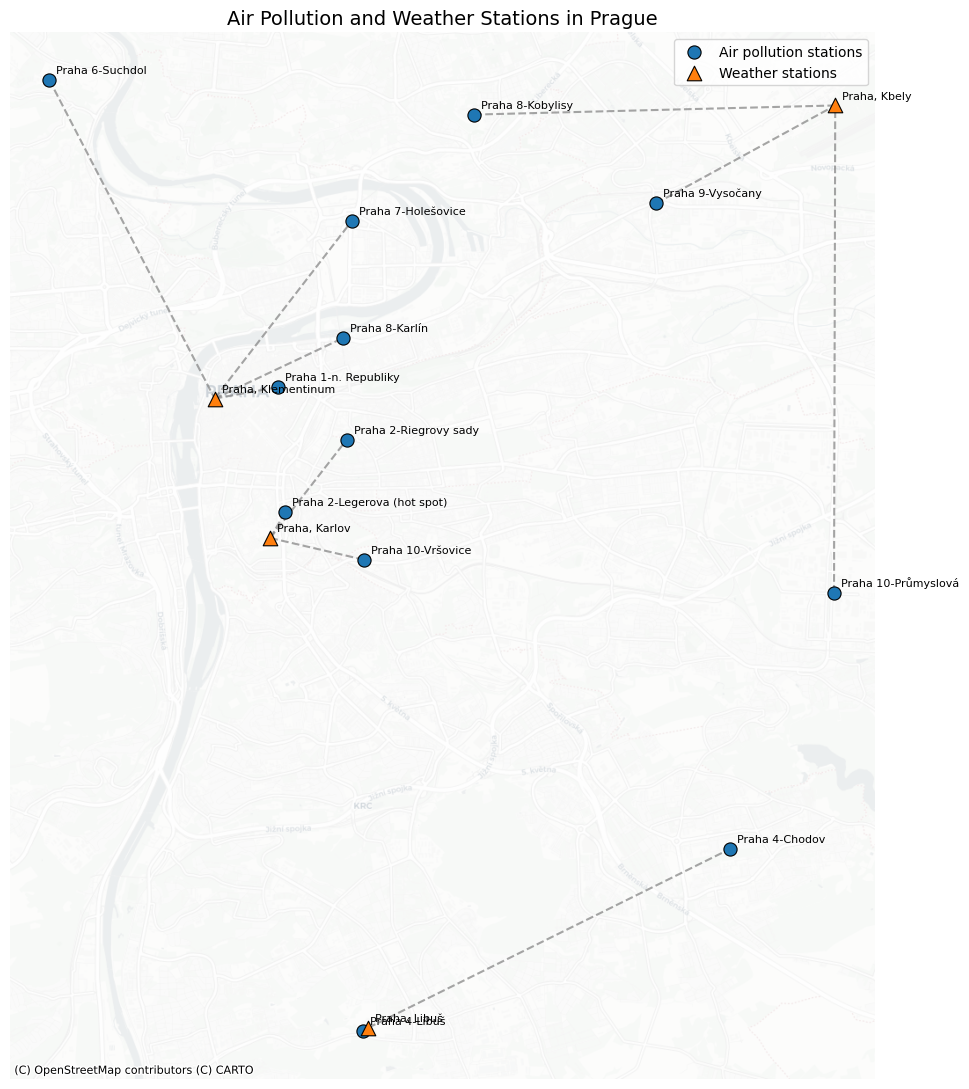

In [106]:

weather_id_col = "weather_station_name"
weather_lat_col = "weather_lat"
weather_lon_col = "weather_lon"

air_id_col = "air_station_name"
air_lat_col = "air_lat"
air_lon_col = "air_lon"

coord_cols = [weather_lat_col, weather_lon_col, air_lat_col, air_lon_col]
df[coord_cols] = df[coord_cols].apply(pd.to_numeric, errors="coerce")

weather_stations = (
    df[[weather_id_col, weather_lat_col, weather_lon_col]]
    .dropna()
    .drop_duplicates()
    .copy()
)

air_stations = (
    df[[air_id_col, air_lat_col, air_lon_col]]
    .dropna()
    .drop_duplicates()
    .copy()
)

pairs = (
    df[
        [
            air_id_col, air_lat_col, air_lon_col,
            weather_id_col, weather_lat_col, weather_lon_col
        ]
    ]
    .dropna()
    .drop_duplicates()
    .copy()
)

gdf_weather = gpd.GeoDataFrame(
    weather_stations,
    geometry=gpd.points_from_xy(
        weather_stations[weather_lon_col],
        weather_stations[weather_lat_col]
    ),
    crs="EPSG:4326"
)

gdf_air = gpd.GeoDataFrame(
    air_stations,
    geometry=gpd.points_from_xy(
        air_stations[air_lon_col],
        air_stations[air_lat_col]
    ),
    crs="EPSG:4326"
)

pair_lines = []
for _, row in pairs.iterrows():
    line = LineString([
        (row[air_lon_col], row[air_lat_col]),
        (row[weather_lon_col], row[weather_lat_col])
    ])
    pair_lines.append({
        "air_station": row[air_id_col],
        "weather_station": row[weather_id_col],
        "geometry": line
    })

gdf_pairs = gpd.GeoDataFrame(pair_lines, crs="EPSG:4326")

gdf_weather = gdf_weather.to_crs(epsg=3857)
gdf_air = gdf_air.to_crs(epsg=3857)
gdf_pairs = gdf_pairs.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 11))

gdf_pairs.plot(
    ax=ax,
    linewidth=1.5,
    alpha=0.7,
    color="gray",
    linestyle="--",
    zorder=1
)

gdf_air.plot(
    ax=ax,
    markersize=90,
    marker="o",
    label="Air pollution stations",
    alpha=1.0,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

gdf_weather.plot(
    ax=ax,
    markersize=110,
    marker="^",
    label="Weather stations",
    alpha=1.0,
    edgecolor="black",
    linewidth=0.8,
    zorder=4
)

for _, row in gdf_air.iterrows():
    ax.annotate(
        row[air_id_col],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        zorder=5
    )

for _, row in gdf_weather.iterrows():
    ax.annotate(
        row[weather_id_col],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        zorder=5
    )

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron,
    alpha=0.45   # smaller alpha = lighter / less visible background
)

ax.set_title("Air Pollution and Weather Stations in Prague", fontsize=14)
ax.set_axis_off()
ax.legend()

plt.tight_layout()
plt.show()

### Histograms of weather and air quality variables

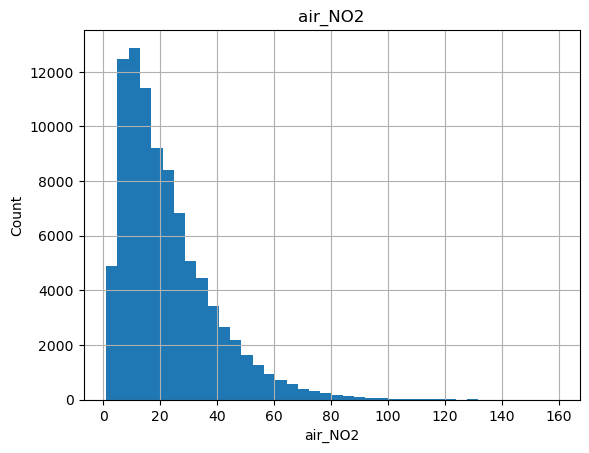

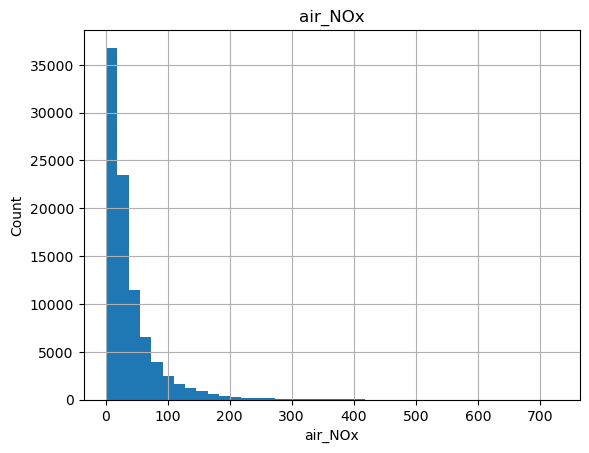

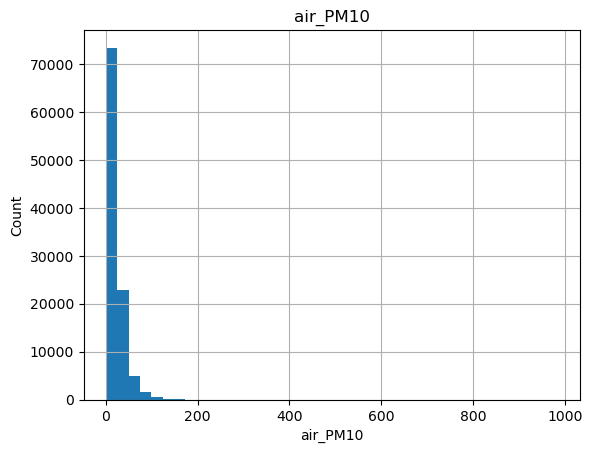

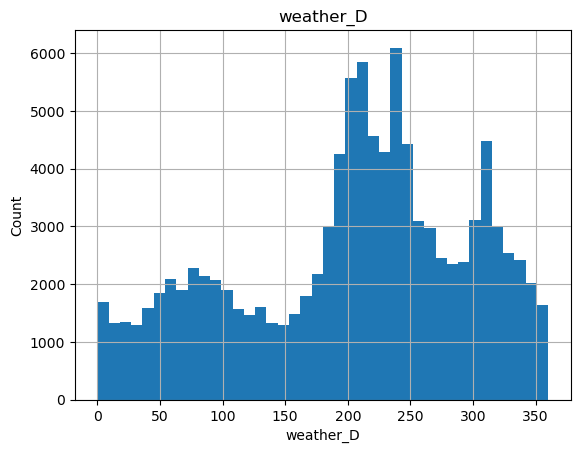

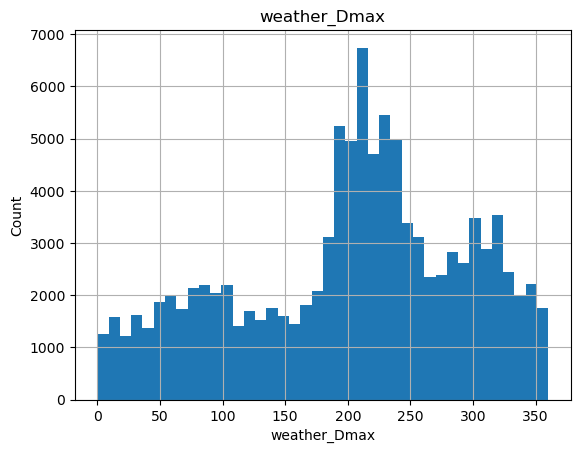

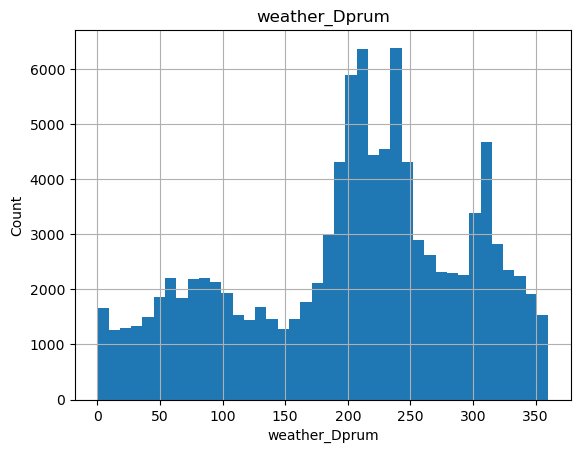

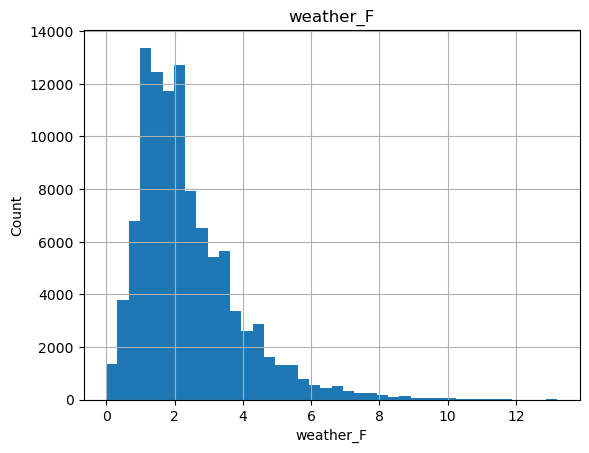

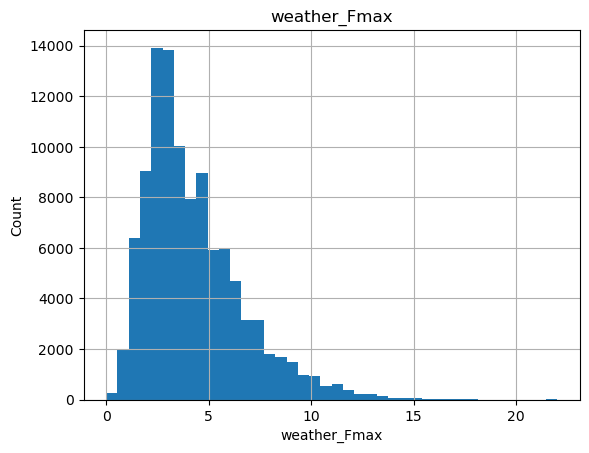

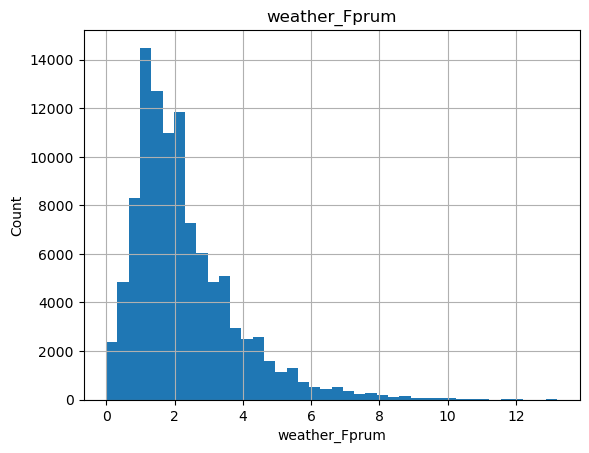

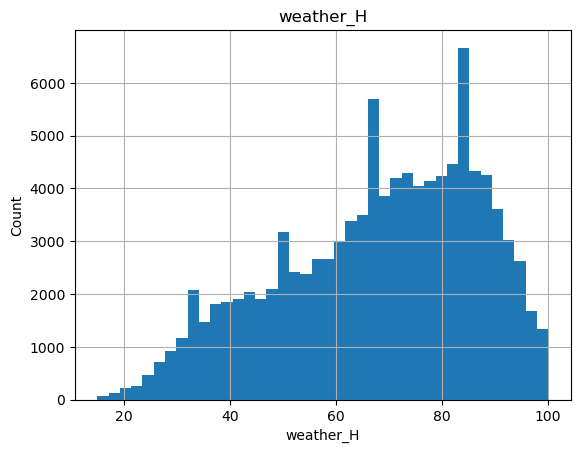

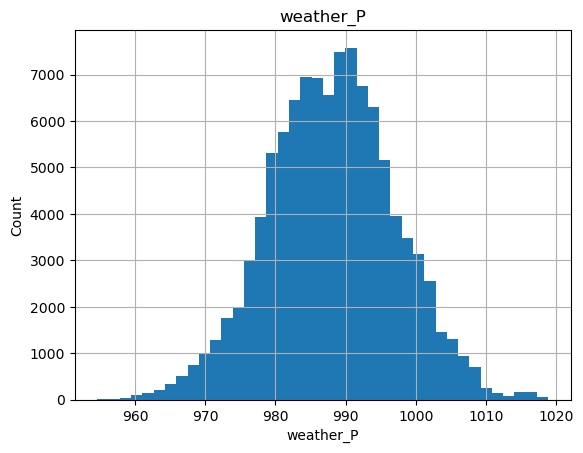

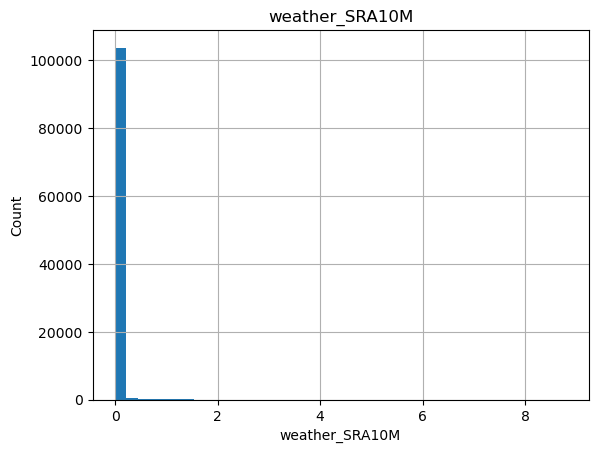

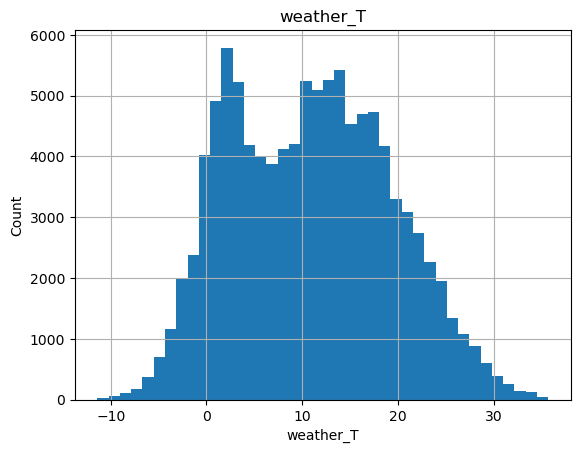

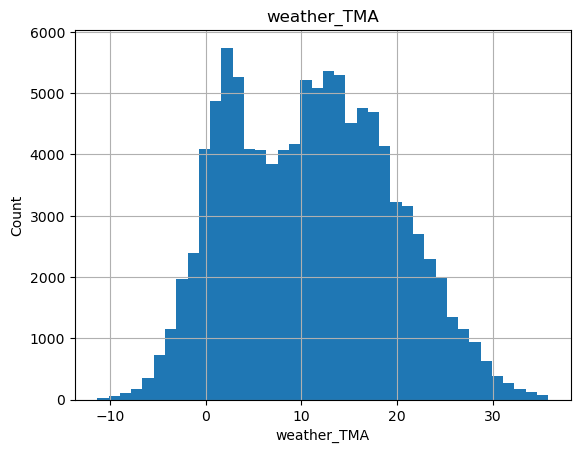

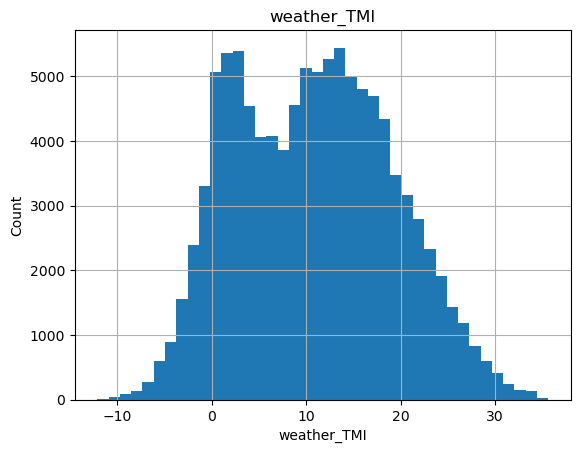

In [107]:
for col in target_cols + weather_cols:
    plt.figure()
    df[col].hist(bins=40)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Time series of air quality variables

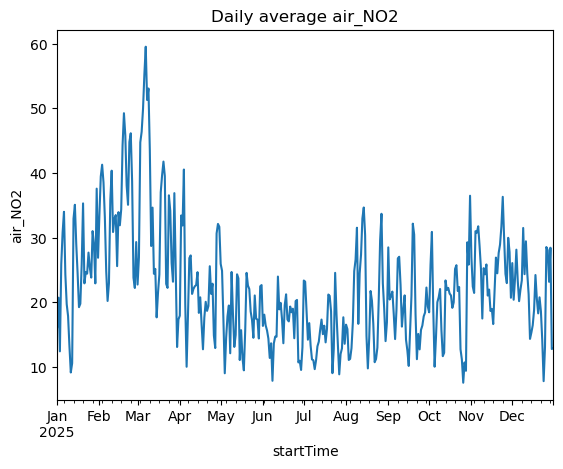

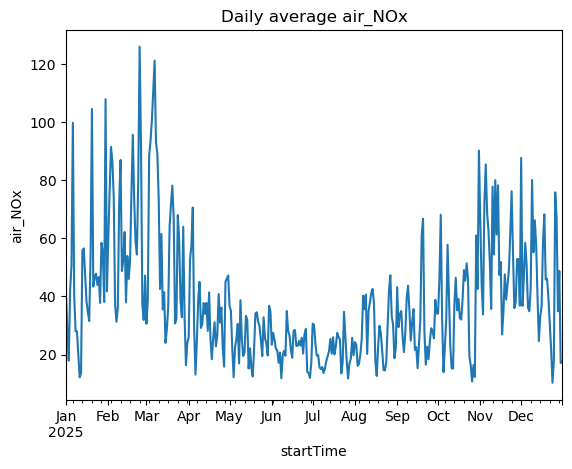

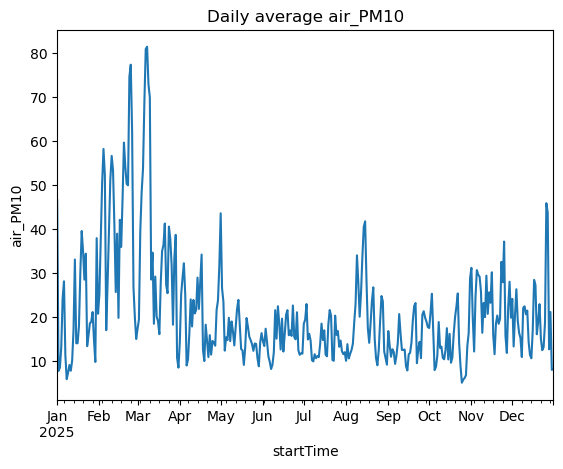

In [108]:
for col in target_cols:
    plt.figure()
    df.set_index("startTime")[col].resample("D").mean().plot()
    plt.title(f"Daily average {col}")
    plt.ylabel(col)
    plt.show()

### Daily patterns

In [ ]:
# in progress 

In [109]:
df.columns

Index(['startTime', 'weather_station_name', 'air_station_name', 'air_NO2',
       'air_NOx', 'air_PM10', 'weather_D', 'weather_Dmax', 'weather_Dprum',
       'weather_F', 'weather_Fmax', 'weather_Fprum', 'weather_H', 'weather_P',
       'weather_SRA10M', 'weather_T', 'weather_TMA', 'weather_TMI', 'air_lon',
       'air_lat', 'weather_lon', 'weather_lat', 'weather_alt', 'distance_km',
       'hour', 'dayofweek', 'is_weekend', 'date', 'month', 'dayofyear',
       'weekday_name'],
      dtype='str')

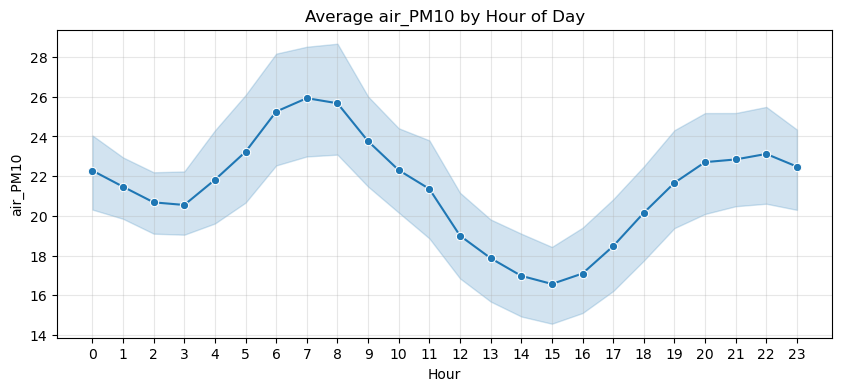

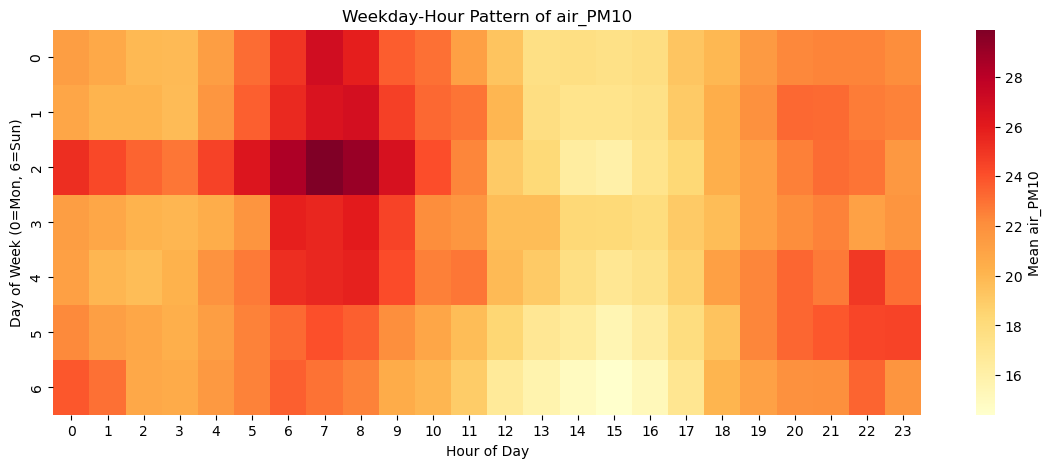

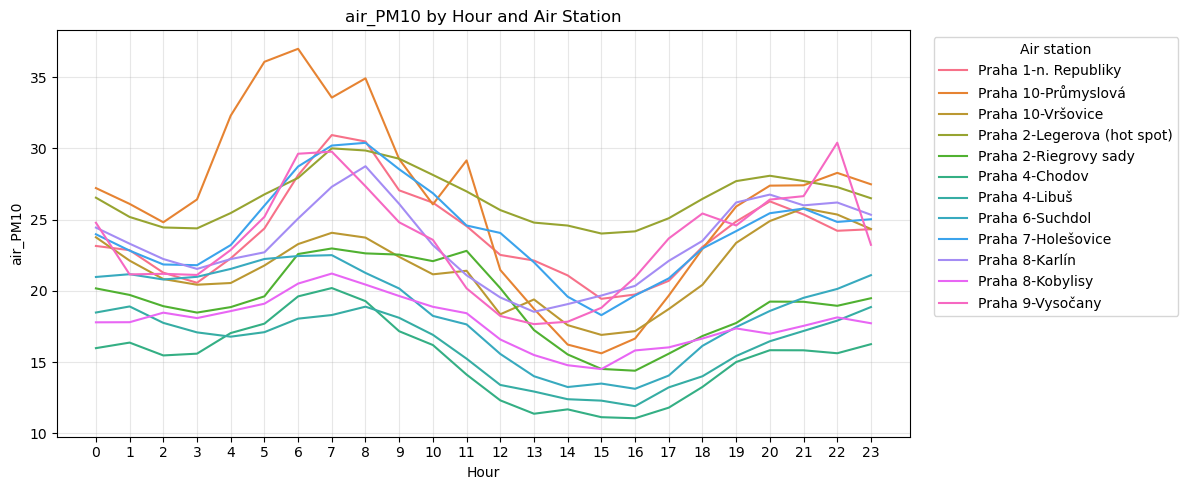

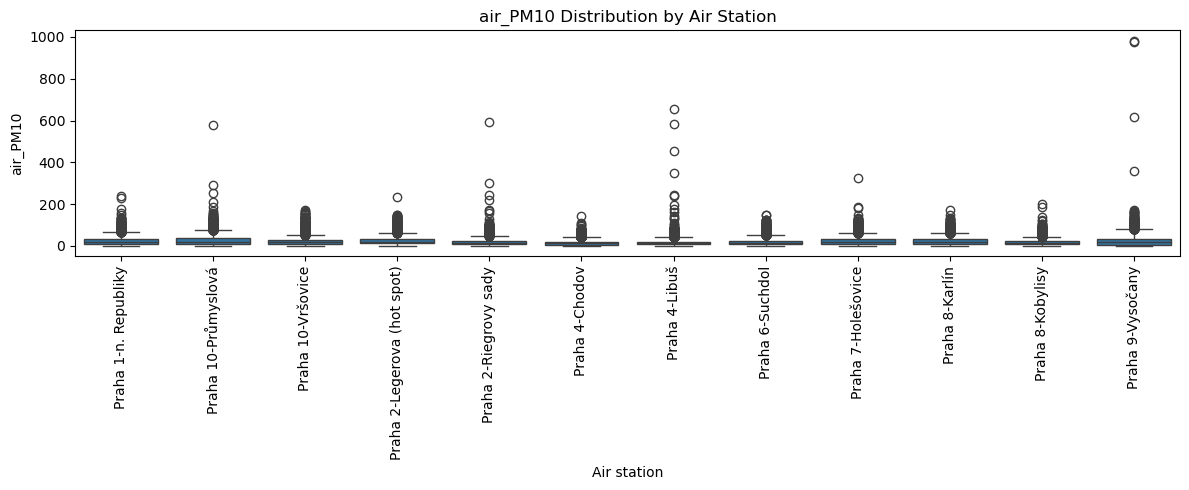

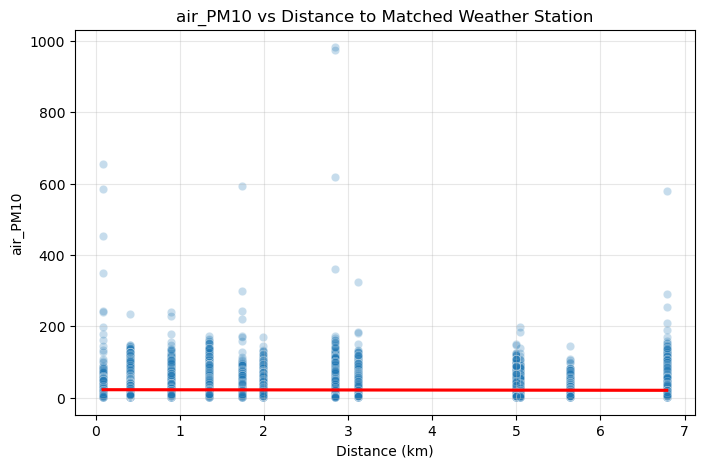

In [110]:
target = "air_PM10"   # or "air_NO2", "air_NOx"

hourly_overall = (
    df.groupby(['air_station_name', "hour"], as_index=False)[target]
    .mean()
)

plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly_overall, x="hour", y=target, marker="o")
plt.title(f"Average {target} by Hour of Day")
plt.xlabel("Hour")
plt.ylabel(target)
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()


hour_weekday = (
    df.groupby(["dayofweek", "hour"], as_index=False)[target]
    .mean()
)

pivot_weekday = hour_weekday.pivot(index="dayofweek", columns="hour", values=target)

plt.figure(figsize=(14, 5))
sns.heatmap(
    pivot_weekday,
    cmap="YlOrRd",
    cbar_kws={"label": f"Mean {target}"}
)
plt.title(f"Weekday-Hour Pattern of {target}")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week (0=Mon, 6=Sun)")
plt.show()


plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df,
    x="hour",
    y=target,
    hue="air_station_name",
    estimator="mean",
    errorbar=None
)
plt.title(f"{target} by Hour and Air Station")
plt.xlabel("Hour")
plt.ylabel(target)
plt.xticks(range(0, 24))
plt.legend(title="Air station", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="air_station_name", y=target)
plt.title(f"{target} Distribution by Air Station")
plt.xlabel("Air station")
plt.ylabel(target)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="distance_km", y=target, alpha=0.25)
sns.regplot(data=df, x="distance_km", y=target, scatter=False, color="red")
plt.title(f"{target} vs Distance to Matched Weather Station")
plt.xlabel("Distance (km)")
plt.ylabel(target)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#here probably outliers have to be filtered otherwise the visualizations are hard to read

### Boxplots of air_quality variables by station

<Figure size 1000x400 with 0 Axes>

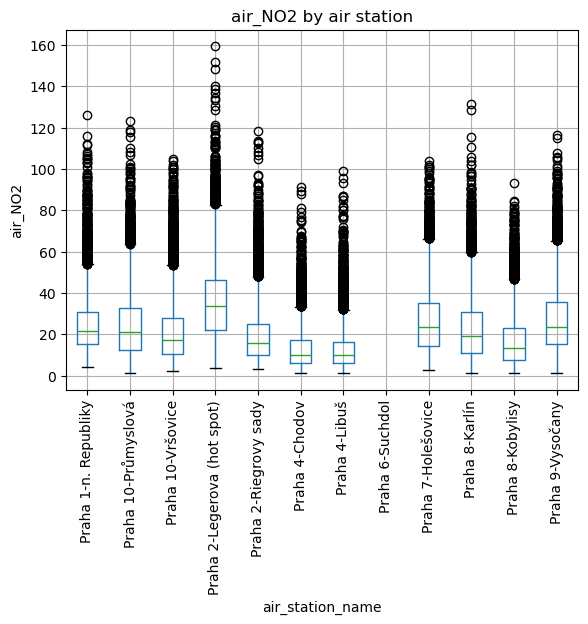

<Figure size 1000x400 with 0 Axes>

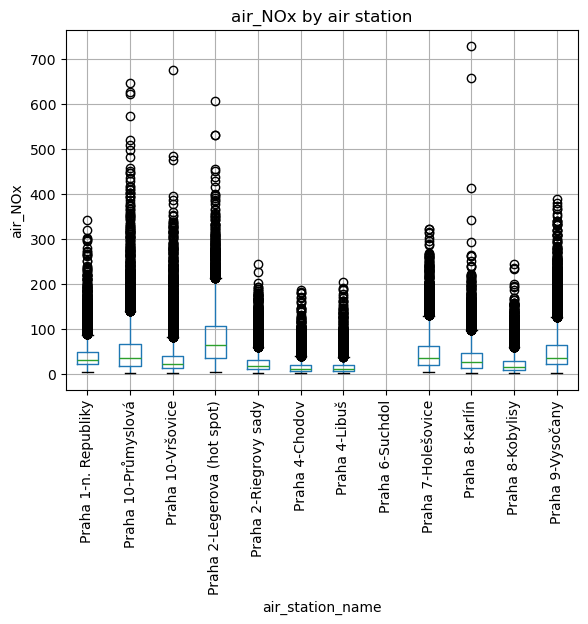

<Figure size 1000x400 with 0 Axes>

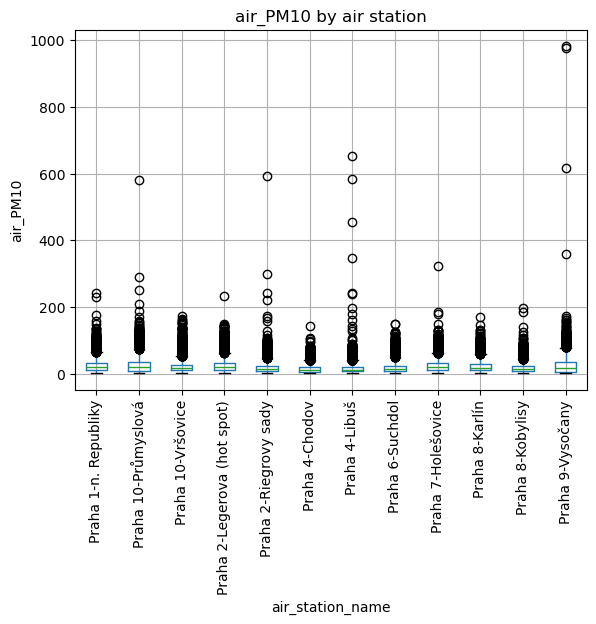

In [111]:
for col in target_cols:
    plt.figure(figsize=(10, 4))
    df.boxplot(column=col, by="air_station_name", rot=90)
    plt.title(f"{col} by air station")
    plt.suptitle("")
    plt.ylabel(col)
    plt.show()

### Scatter plots of weather vs air quality variables

<Figure size 640x480 with 0 Axes>

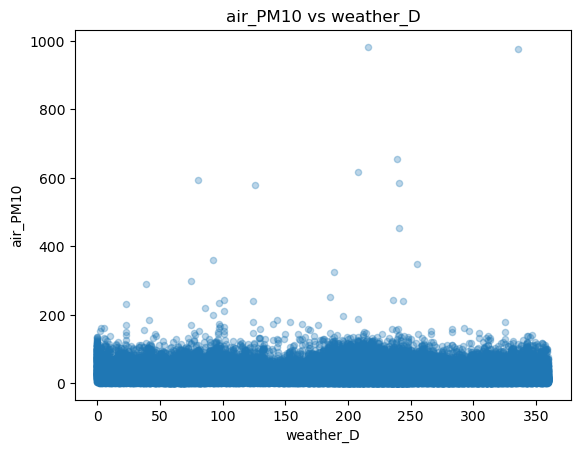

<Figure size 640x480 with 0 Axes>

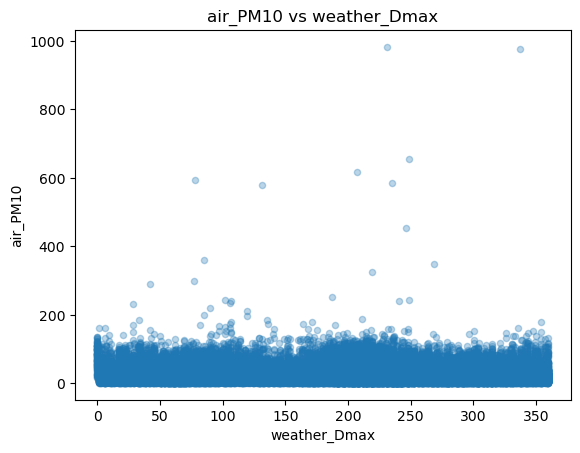

<Figure size 640x480 with 0 Axes>

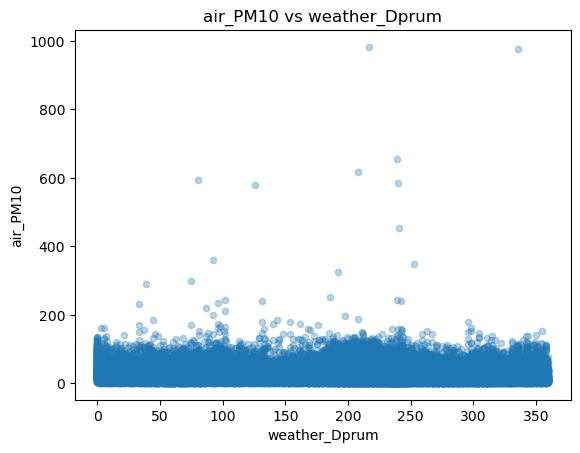

<Figure size 640x480 with 0 Axes>

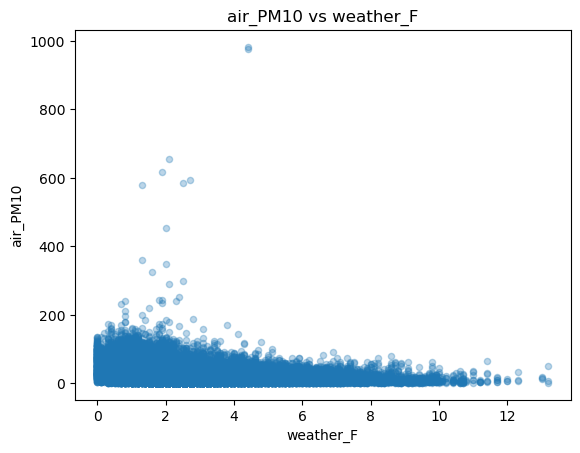

<Figure size 640x480 with 0 Axes>

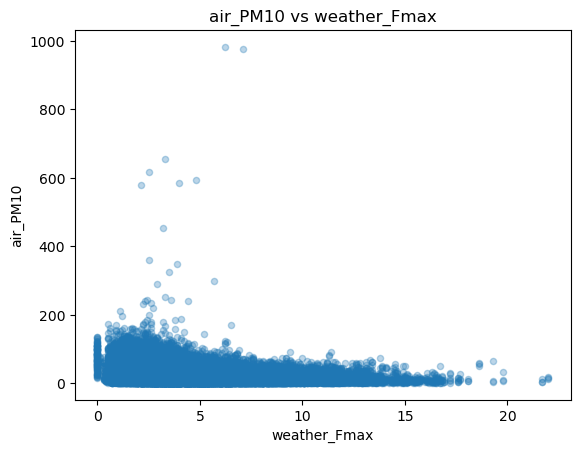

<Figure size 640x480 with 0 Axes>

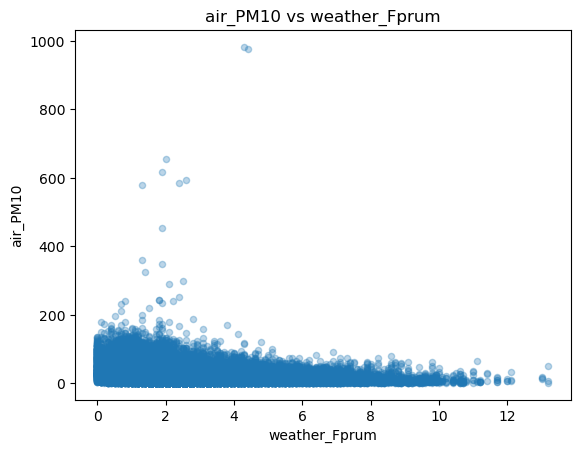

<Figure size 640x480 with 0 Axes>

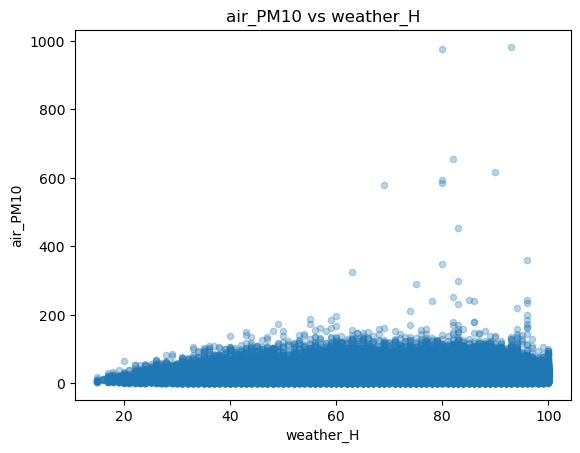

<Figure size 640x480 with 0 Axes>

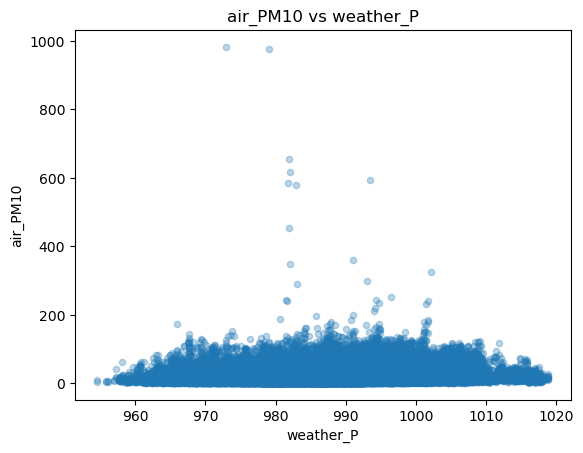

<Figure size 640x480 with 0 Axes>

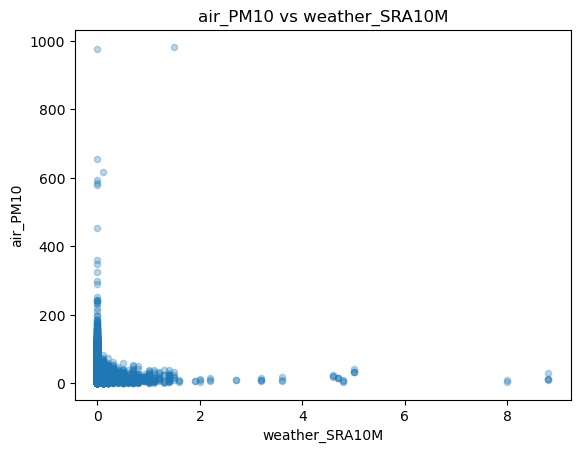

<Figure size 640x480 with 0 Axes>

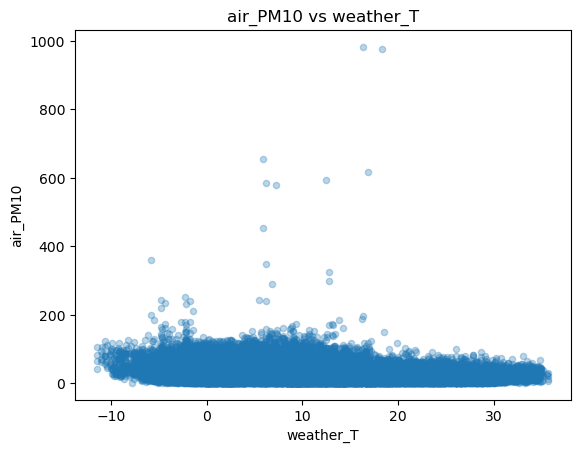

<Figure size 640x480 with 0 Axes>

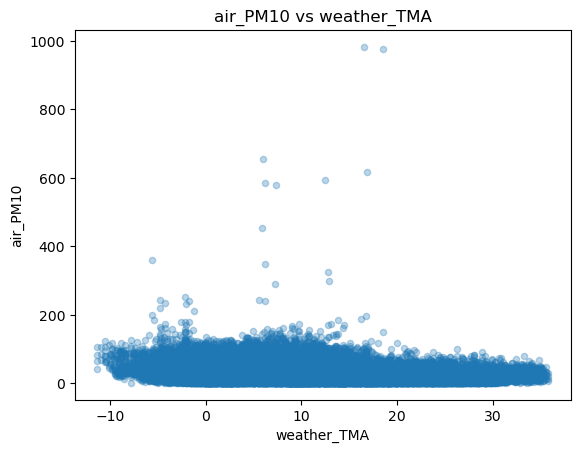

<Figure size 640x480 with 0 Axes>

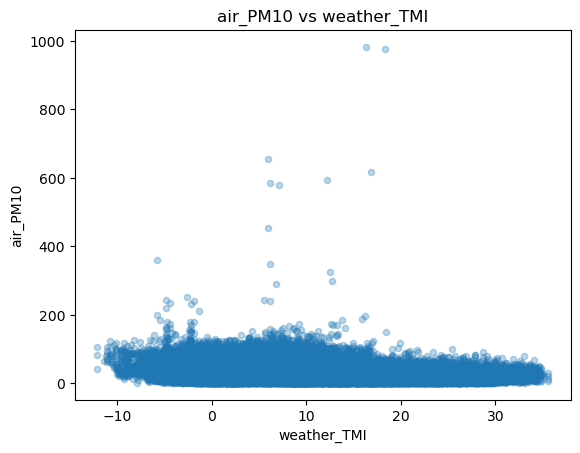

In [112]:
# Start with air_PM10
target = "air_PM10"

for col in weather_cols:
    plt.figure()
    df.plot.scatter(x=col, y=target, alpha=0.3)
    plt.title(f"{target} vs {col}")
    plt.show()

### Correlations

In [113]:
corr_cols = target_cols + weather_cols + spatial_cols

corr_matrix = df[corr_cols].corr()

corr_matrix[target_cols].sort_values("air_PM10", ascending=False)

,air_NO2,air_NOx,air_PM10
air_PM10,0.518664,0.531640,1.000000
air_NOx,0.826255,1.000000,0.531640
air_NO2,1.000000,0.826255,0.518664
weather_P,0.188604,0.149365,0.156776
weather_lat,0.200523,0.196041,0.112370
weather_H,0.087028,0.179475,0.089999
air_lat,0.187727,0.146150,0.058223
air_lon,-0.087055,-0.035002,0.010891
weather_lon,-0.029497,0.010233,0.010649
weather_SRA10M,-0.014458,-0.014713,-0.020993


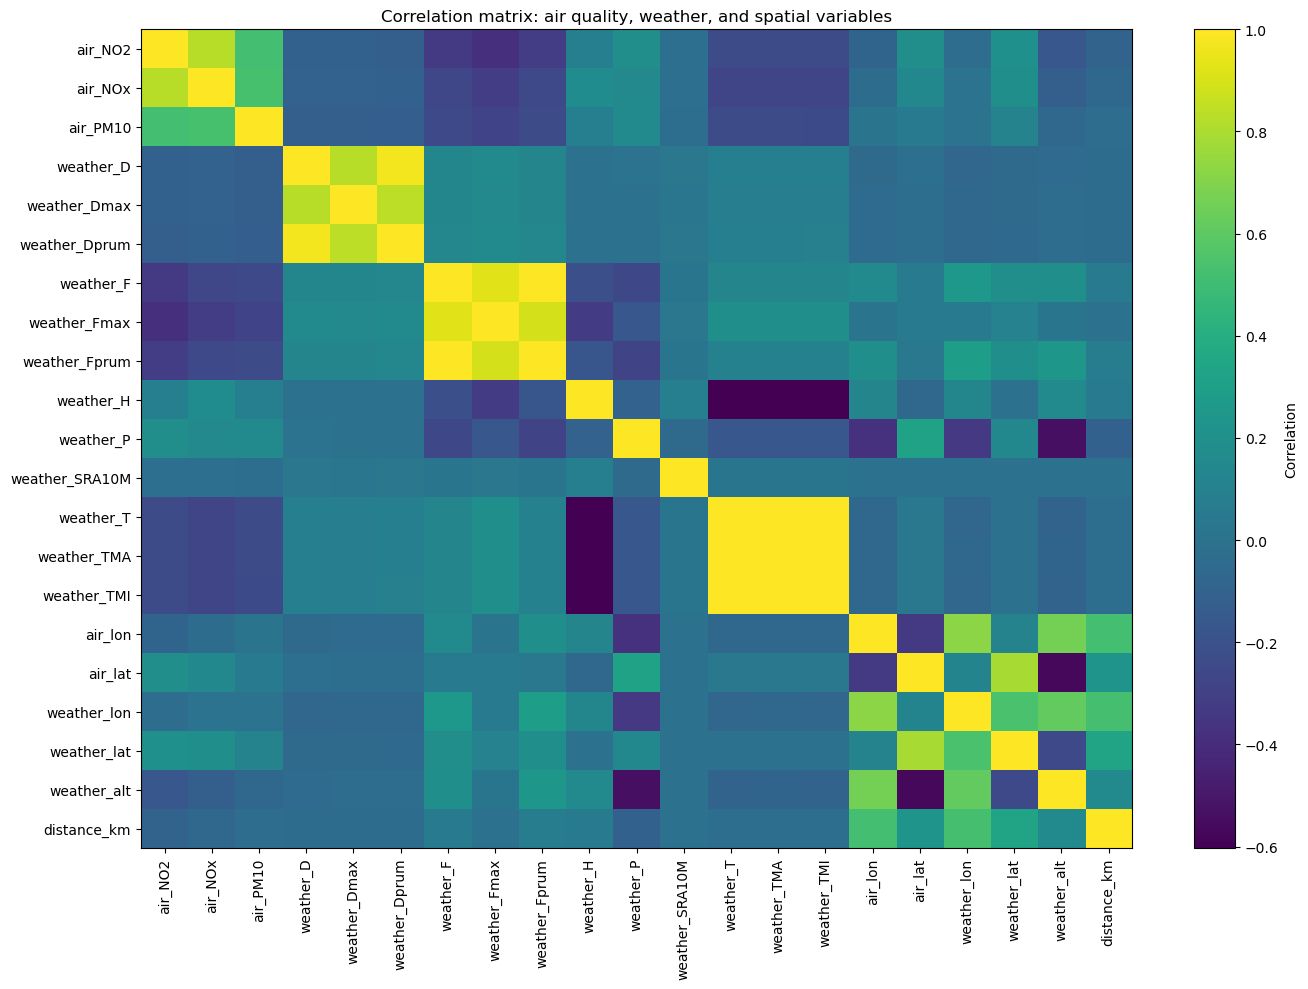

In [114]:
### Heatmap
plt.figure(figsize=(14, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

plt.title("Correlation matrix: air quality, weather, and spatial variables")
plt.tight_layout()
plt.show()

### Convert and create explanatory variables

In [115]:
# convert wind to vector
#wind_u > 0  means wind blows toward the east
#wind_u < 0  means wind blows toward the west
#wind_v > 0  means wind blows toward the north
#wind_v < 0  means wind blows toward the south

theta = np.deg2rad(df_merged["weather_D"])

# Wind vector showing where the wind is blowing TO
df["wind_u"] = -df["weather_F"] * np.sin(theta)
df["wind_v"] = -df["weather_F"] * np.cos(theta)


df["startTime"] = pd.to_datetime(df["startTime"])
df = df.sort_values(["air_station_name", "startTime"]).reset_index(drop=True)

meteo_vars = ["weather_F", "wind_u", "wind_v", "weather_T", "weather_H", "weather_P"]

for var in meteo_vars:
    df[f"{var}_lag1"] = df.groupby("air_station_name")[var].shift(1)

    df[f"{var}_mean3"] = (
        df.groupby("air_station_name")[var]
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )

    df[f"{var}_mean6"] = (
        df.groupby("air_station_name")[var]
        .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
    )

for window in [3, 6, 12, 24]:
    df[f"precip_sum{window}"] = (
        df.groupby("air_station_name")["weather_SRA10M"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).sum())
    )

df["weather_P_change6"] = (
    df["weather_P"] - df.groupby("air_station_name")["weather_P"].shift(6)
)

In [116]:
df 

,startTime,weather_station_name,air_station_name,air_NO2,air_NOx,air_PM10,weather_D,weather_Dmax,weather_Dprum,weather_F,...,weather_H_mean3,weather_H_mean6,weather_P_lag1,weather_P_mean3,weather_P_mean6,precip_sum3,precip_sum6,precip_sum12,precip_sum24,weather_P_change6
0,2025-01-01 00:00:00,"Praha, Klementinum",Praha 1-n. Republiky,28.3,118.6,240.9,124.0,107.0,131.0,0.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 01:00:00,"Praha, Klementinum",Praha 1-n. Republiky,23.9,97.0,230.2,23.0,28.0,33.0,0.7,...,86.000000,86.000000,1001.8,1001.800000,1001.800000,0.0,0.0,0.0,0.0,NaN
2,2025-01-01 02:00:00,"Praha, Klementinum",Praha 1-n. Republiky,24.7,107.7,177.9,325.0,354.0,296.0,0.8,...,84.500000,84.500000,1001.5,1001.650000,1001.650000,0.0,0.0,0.0,0.0,NaN
3,2025-01-01 03:00:00,"Praha, Klementinum",Praha 1-n. Republiky,30.0,146.0,157.0,283.0,248.0,242.0,0.4,...,83.666667,83.666667,1001.2,1001.500000,1001.500000,0.0,0.0,0.0,0.0,NaN
4,2025-01-01 04:00:00,"Praha, Klementinum",Praha 1-n. Republiky,28.7,159.7,128.2,248.0,214.0,222.0,0.7,...,82.666667,83.500000,1001.1,1001.266667,1001.400000,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104659,2025-12-31 19:00:00,"Praha, Kbely",Praha 9-Vysočany,13.8,18.9,1.0,249.0,248.0,249.0,7.8,...,74.000000,77.500000,979.2,979.166667,979.300000,0.0,0.2,0.2,0.2,-0.7
104660,2025-12-31 20:00:00,"Praha, Kbely",Praha 9-Vysočany,13.4,17.0,1.0,245.0,245.0,245.0,7.4,...,73.333333,75.833333,979.2,979.166667,979.183333,0.0,0.0,0.2,0.2,0.3
104661,2025-12-31 21:00:00,"Praha, Kbely",Praha 9-Vysočany,13.0,15.9,5.0,239.0,241.0,239.0,7.9,...,73.666667,74.333333,979.6,979.333333,979.233333,0.0,0.0,0.2,0.2,0.4
104662,2025-12-31 22:00:00,"Praha, Kbely",Praha 9-Vysočany,12.6,14.7,39.4,232.0,234.0,232.0,6.8,...,74.333333,74.166667,979.5,979.433333,979.300000,0.0,0.0,0.2,0.2,0.1


In [117]:
df["weather_station_name"].unique()

<StringArray>
['Praha, Klementinum', 'Praha, Kbely', 'Praha, Karlov', 'Praha, Libuš']
Length: 4, dtype: str

### **Mapping the wind direction to air quality**

In [ ]:
# in progress

In [ ]:
#!pip install windrose

<Figure size 800x800 with 0 Axes>

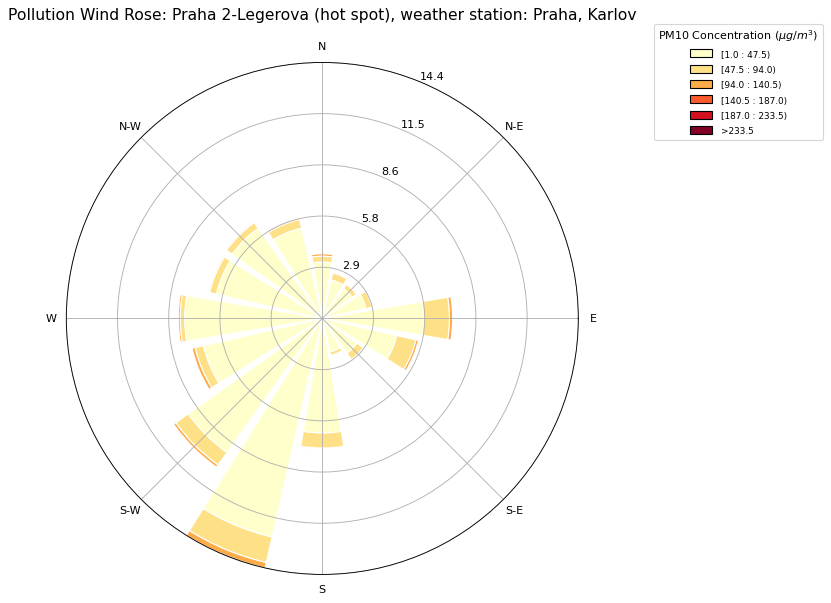

In [118]:
target_station = "Praha 2-Legerova (hot spot)"

df_single_station = df[df['air_station_name'] == target_station]
corresponding_weather_station = df_single_station["weather_station_name"].iloc[0]

plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax()

ax.bar(
    df_single_station['weather_Dprum'], 
    df_single_station['air_PM10'], 
    normed=True,             
    opening=0.85,            
    edgecolor='white',       
    cmap=cm.YlOrRd,          
    nsector=16               
)

ax.set_legend(title=r"PM10 Concentration ($\mu g/m^3$)", bbox_to_anchor=(1.15, 0.85))
plt.title(f"Pollution Wind Rose: {target_station}, weather station: {corresponding_weather_station}", fontsize=14, pad=20)
plt.show()

## Baseline modeling
just a draft, the variables are not prepared

In [ ]:
def run_rf_model(df, target, predictor_cols):
    df_model = df[[target, "startTime"] + predictor_cols].dropna(subset=[target]).copy()
    df_model = df_model.sort_values("startTime")

    split_index = int(len(df_model) * 0.8)

    train = df_model.iloc[:split_index].copy()
    test = df_model.iloc[split_index:].copy()

    X_train = train[predictor_cols]
    y_train = train[target]

    X_test = test[predictor_cols]
    y_test = test[target]

    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            min_samples_leaf=5,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    metrics = {
        "target": target,
        "n_train": len(train),
        "n_test": len(test),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred)
    }

    importance = pd.DataFrame({
        "target": target,
        "variable": predictor_cols,
        "importance": model.named_steps["model"].feature_importances_
    }).sort_values("importance", ascending=False)

    results = test[["startTime"]].copy()
    results["actual"] = y_test.values
    results["predicted"] = y_pred
    results["error"] = results["actual"] - results["predicted"]

    return model, metrics, importance, results

In [ ]:
models = {}
metrics_list = []
importance_list = []

for target in target_cols:
    model, metrics, importance, results = run_rf_model(df, target, predictor_cols)

    models[target] = model
    metrics_list.append(metrics)
    importance_list.append(importance)

metrics_table = pd.DataFrame(metrics_list)
importance_table = pd.concat(importance_list, ignore_index=True)

metrics_table

NameError: name 'predictor_cols' is not defined

## Alternative using time series split

In [119]:
#### alternative using time series split

def run_rf_model(df, target, predictor_cols, n_splits=5):
    df_model = df[[target, "startTime"] + predictor_cols].dropna(subset=[target]).copy()
    df_model = df_model.sort_values("startTime").reset_index(drop=True)

    X = df_model[predictor_cols]
    y = df_model[target].values

    tscv = TimeSeriesSplit(n_splits=n_splits)

    fold_metrics = []
    importances = []
    results_list = []
    last_model = None

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                min_samples_leaf=5,
                n_jobs=-1
            ))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_metrics.append({
            "target": target,
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
            "R2": r2_score(y_test, y_pred)
        })

        importances.append(model.named_steps["model"].feature_importances_)

        res = df_model.loc[test_idx, ["startTime"]].copy()
        res["fold"] = fold
        res["actual"] = y_test
        res["predicted"] = y_pred
        res["error"] = res["actual"] - res["predicted"]
        results_list.append(res)

        last_model = model

    # aggregate metrics and importances
    metrics_df = pd.DataFrame(fold_metrics)
    importance_mean = np.mean(importances, axis=0)
    importance_df = pd.DataFrame({
        "target": target,
        "variable": predictor_cols,
        "importance": importance_mean
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    results_df = pd.concat(results_list, ignore_index=True).sort_values(["fold", "startTime"]).reset_index(drop=True)

    metrics_summary = {
        "target": target,
        "n_splits": n_splits,
        "metrics_per_fold": metrics_df,
        "metrics_mean": metrics_df.drop(columns=["target", "fold"]).mean().to_dict(),
        "metrics_std": metrics_df.drop(columns=["target", "fold"]).std().to_dict()
    }

    return last_model, metrics_summary, importance_df, results_df

In [ ]:
models = {}
metrics_per_fold_list = []
metrics_mean_list = []
importance_list = []
predictions_list = []

predictor_cols = (
    weather_cols
    + spatial_cols
    + ["hour", "dayofweek", "is_weekend", "month", "dayofyear", "wind_u", "wind_v"]
)

for target in target_cols:
    model, metrics_summary, importance_df, results_df = run_rf_model(df, target, predictor_cols, n_splits=5)

    models[target] = model
    # per-fold metrics (DataFrame inside metrics_summary)
    metrics_per_fold_list.append(metrics_summary["metrics_per_fold"].assign(target=target))
    # mean metrics (dict -> row)
    metrics_mean_list.append({"target": target, **metrics_summary["metrics_mean"]})
    importance_list.append(importance_df.assign(target=target))
    predictions_list.append(results_df.assign(target=target))

metrics_per_fold = pd.concat(metrics_per_fold_list, ignore_index=True)
metrics_mean_table = pd.DataFrame(metrics_mean_list)    
importance_table = pd.concat(importance_list, ignore_index=True)
predictions_table = pd.concat(predictions_list, ignore_index=True)

In [ ]:
#trained for ... 

In [ ]:
metrics_per_fold

,target,fold,n_train,n_test,MAE,RMSE,R2
0,air_NO2,1,1246,1242,7.770581,9.695259,0.360808
1,air_NO2,2,2488,1242,6.045760,7.348803,0.230880
2,air_NO2,3,3730,1242,6.900928,9.230509,0.240378
3,air_NO2,4,4972,1242,9.634463,12.123028,0.234688
4,air_NO2,5,6214,1242,7.503609,9.513179,0.135394
5,air_NOx,1,1245,1242,28.759670,43.733007,0.332848
6,air_NOx,2,2487,1242,26.805222,36.458293,0.426598
7,air_NOx,3,3729,1242,32.544340,40.321605,-0.364177
8,air_NOx,4,4971,1242,24.691238,33.747063,0.487691
9,air_NOx,5,6213,1242,19.206941,27.750601,0.306349


In [ ]:
metrics_mean_table

,target,n_train,n_test,MAE,RMSE,R2
0,air_NO2,3730.0,1242.0,7.571068,9.582156,0.240430
1,air_NOx,3729.0,1242.0,26.401482,36.402114,0.237862
2,air_PM10,4263.0,1421.0,12.273014,15.416730,-0.416158


C:\Users\jachy\AppData\Local\Temp\ipykernel_4808\3808710444.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='variable', palette='viridis')


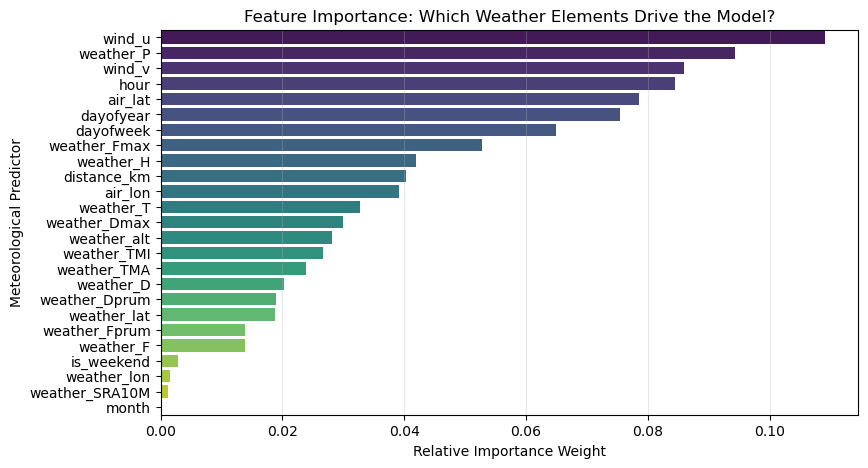

In [ ]:
import seaborn as sns

plt.figure(figsize=(9, 5))

sns.barplot(data=importance_df, x='importance', y='variable', palette='viridis')

plt.title('Feature Importance: Which Weather Elements Drive the Model?')
plt.xlabel('Relative Importance Weight')
plt.ylabel('Meteorological Predictor')
plt.grid(axis='x', alpha=0.3)
plt.show()